In [35]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import time
import shap
import optuna

In [36]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [37]:
annotated_control_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")
annotated_control_confident_df  = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar_confident-cellular_drug_context-control.csv")

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_18332/3863710211.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_control_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")
/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_18332/3863710211.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_control_confident_df  = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar_confident-cellular_drug_context-control.csv")


## Select Dataset for Prediction

In [39]:
annotated_variants_df = annotated_control_df

# Filter for EG 

In [40]:
#Keep only rows with EG drugs, cell lines and drop 'MC' source
annotated_variants_df = annotated_variants_df[annotated_variants_df['Drug'].isin(['PIC', 'SCH', 'LIN'])]
annotated_variants_df = annotated_variants_df[annotated_variants_df['Cell_Line'].isin(['HT29', 'A375'])]
annotated_variants_df = annotated_variants_df[annotated_variants_df['Source'] != 'MC']

In [41]:
len(annotated_variants_df)

84024

# Classification

## Encode Labels

In [42]:
#Define Sensitivity, Neutral and Resistance classes
annotated_variants_df['Class'] = annotated_variants_df['Hit_class'].replace({'negative': 'Sensitivity', 'non-hit': 'Neutral', 'positive': 'Resistance'})
annotated_variants_df.drop(columns=['Hit_class'], inplace=True)

#Encode Classes
le = LabelEncoder()
annotated_variants_df['Class_encoded'] = le.fit_transform(annotated_variants_df['Class'])

In [43]:
# Check encoding mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

Label mapping: {'Neutral': np.int64(0), 'Resistance': np.int64(1), 'Sensitivity': np.int64(2)}


In [44]:
annotated_variants_df['Class_encoded'].value_counts()

Class_encoded
0    82785
1      788
2      451
Name: count, dtype: int64

In [45]:
annotated_variants_df['Class'].value_counts()

Class
Neutral        82785
Resistance       788
Sensitivity      451
Name: count, dtype: int64

## Handle Class Imbalance

In [46]:
class_counts = annotated_variants_df['Class'].value_counts()
class_proportions= annotated_variants_df['Class'].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", (class_proportions*100).round(2))

Class counts:
 Class
Neutral        82785
Resistance       788
Sensitivity      451
Name: count, dtype: int64

Class percentage:
 Class
Neutral        98.53
Resistance      0.94
Sensitivity     0.54
Name: proportion, dtype: float64


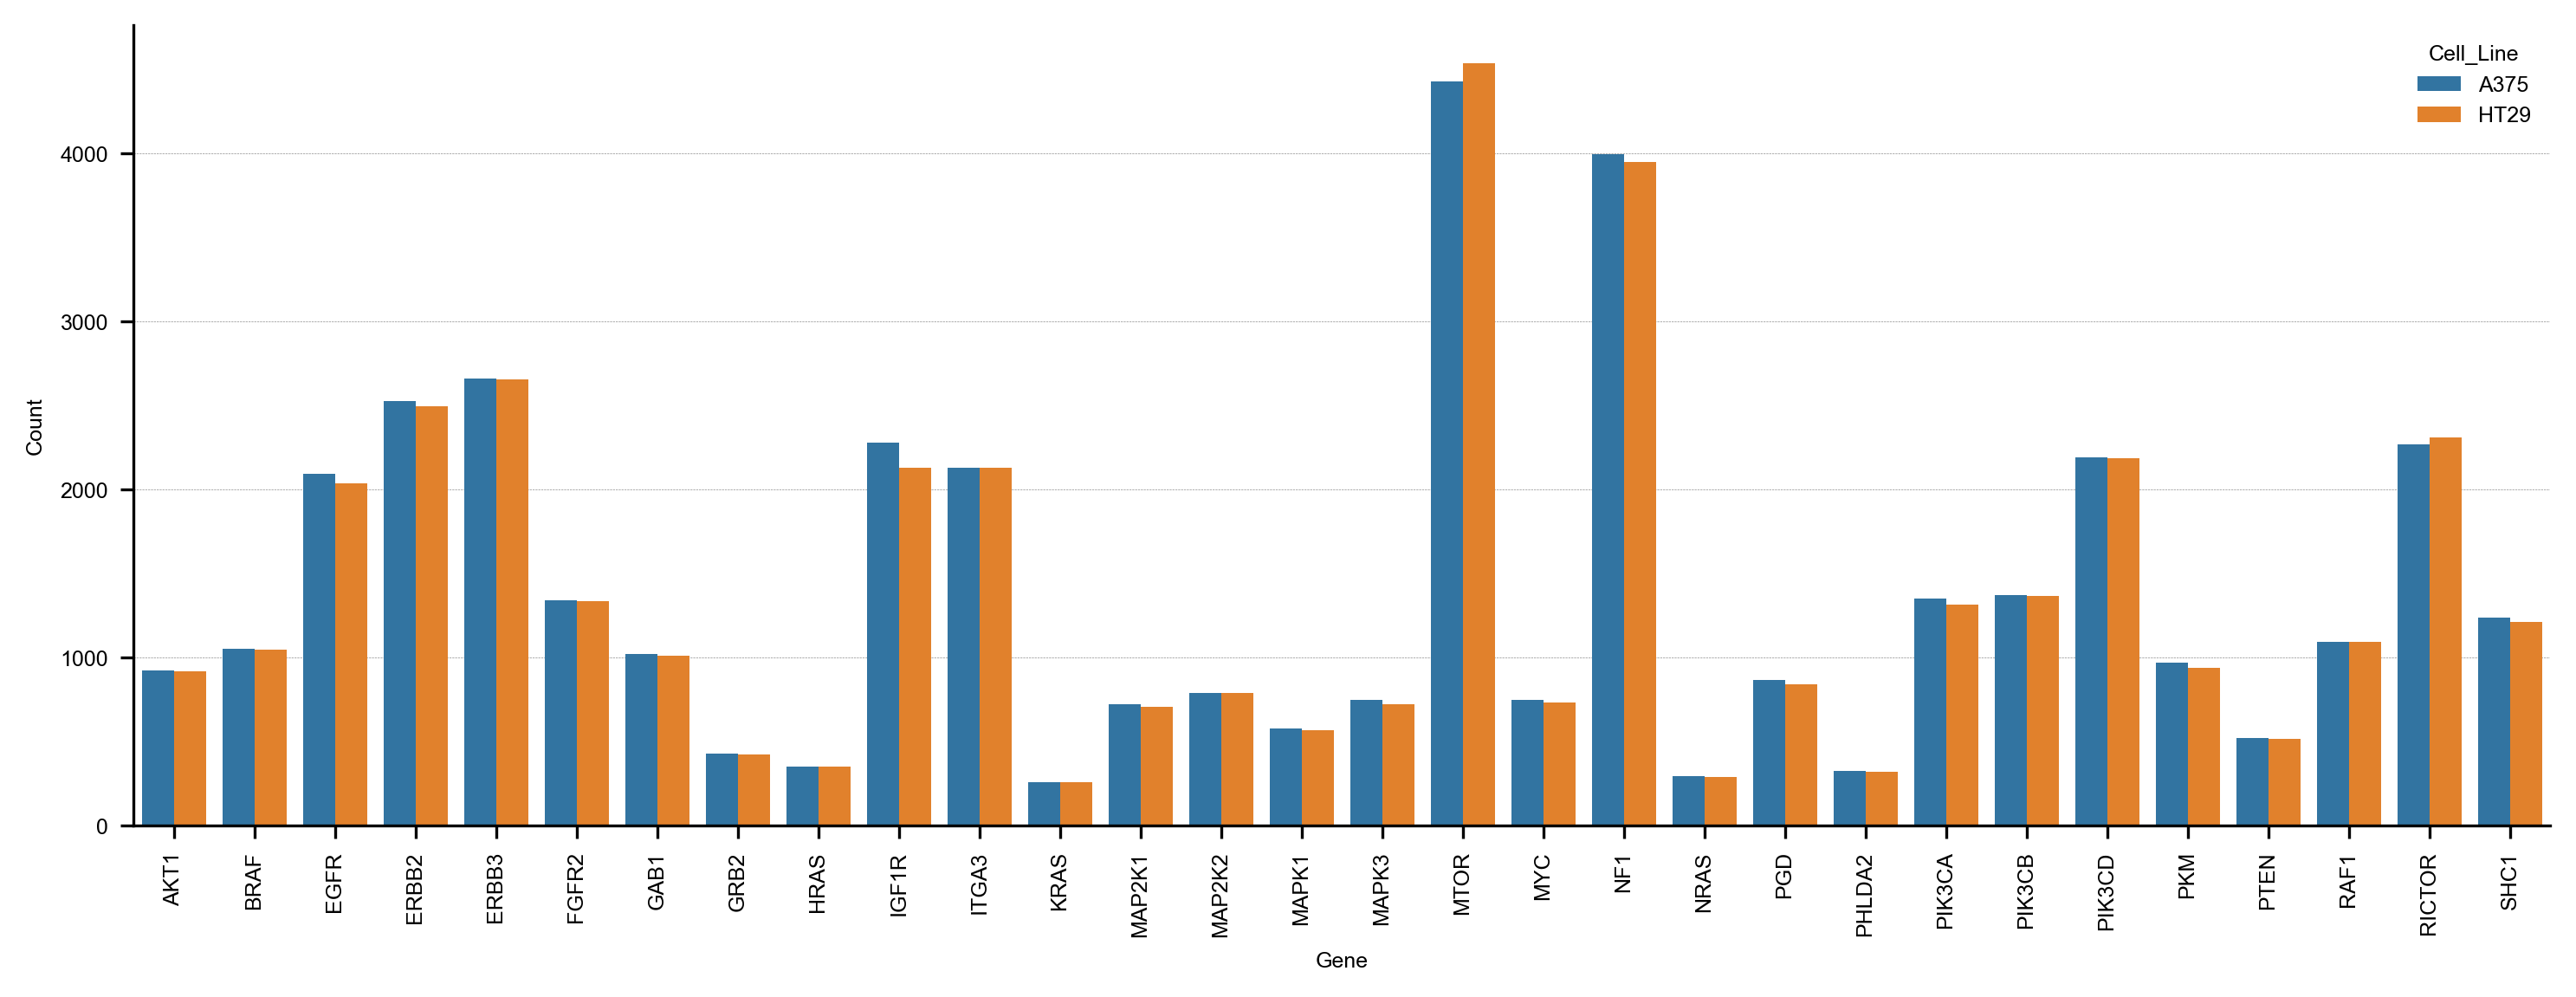

In [47]:
counts_before_DS = (
    annotated_variants_df
    .groupby(["Cell_Line", "Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_before_DS = counts_before_DS[counts_before_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_before_DS,
    x="Gene", y="Count", hue='Cell_Line', errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [48]:
def stratified_downsampling(df, class_col, random_state=None):
    #Infer majority class + target size (length of the second largest class)
    class_counts = df[class_col].value_counts()
    majority_class = class_counts.idxmax()
    target_size = class_counts.nlargest(2).iloc[-1]

    #Separate majority class and other classes
    major_df = df[df[class_col] == majority_class]
    other_df = df[df[class_col] != majority_class]

    # If majority already not bigger than target, nothing to do
    if len(major_df) <= target_size:
        return df.copy()
    
    #Compute distribution of the majority df across Cell_Line and Gene
    major_distribution = (
        major_df
        .groupby(['Cell_Line', 'Gene'])
        .size()
        .reset_index(name='Count')
    )

    # Calculate proportions
    major_distribution['Proportion'] = major_distribution['Count'] / major_distribution['Count'].sum()

    # Determine number of samples to select from each Cell_Line × Gene group
    major_distribution['Target'] = np.floor(major_distribution['Proportion'] * target_size).astype(int)

    # Adjust target to ensure total matches target size 
    # i.e., distribute the remaining samples to the groups with the largest fractional remainders
    difference = target_size - major_distribution['Target'].sum()
    if difference > 0:
        fractional_parts = major_distribution['Proportion'] * target_size - major_distribution['Target']
        top_idx = fractional_parts.nlargest(difference).index
        major_distribution.loc[top_idx, 'Target'] += 1

    #Perform stratified downsampling
    downsampled_major_dfs= []
    for _, row in major_distribution.iterrows():
        cell_line = row['Cell_Line']
        gene = row['Gene']
        target = row['Target']

        subset = major_df[(major_df['Cell_Line'] == cell_line) & (major_df['Gene'] == gene)]

        if target > 0:
            n_sampled = min(target, len(subset)) # in case it is a very small group - but can lead to less samples than target_size overall
            downsampled_major_dfs.append(subset.sample(n=n_sampled, random_state=random_state))
    
    #Keep the indices until after the Top up step
    downsampled_majority_class_df = pd.concat(downsampled_major_dfs, axis=0)

    #Top up if needed (if very small groups caused total to be less than target_size)
    current_size = len(downsampled_majority_class_df)
    missing = target_size - current_size

    if missing>0: #ask supervisor if this is really needed
        remaining_samples = major_df.loc[~major_df.index.isin(downsampled_majority_class_df.index)]
        assert not remaining_samples.empty, ("Logic error: remaining_samples is empty but target_size not reached.")
        extra_n= min(missing, len(remaining_samples))
        extra_samples = remaining_samples.sample(n=extra_n, random_state=random_state)

        #Random subsample from the remaining samples now
        downsampled_majority_class_df = pd.concat([downsampled_majority_class_df, extra_samples], axis=0)

    # Reset index only at the end
    downsampled_majority_class_df = downsampled_majority_class_df.reset_index(drop=True)

    #Combine downsampled majority class with other classes
    balanced_df = pd.concat([downsampled_majority_class_df, other_df], ignore_index=True)

    return balanced_df

In [49]:
#Balanced Dataset
annotated_variants_df_balanced = stratified_downsampling(annotated_variants_df,class_col='Class', random_state=1)

In [50]:
print("Final class counts:")
print(annotated_variants_df_balanced["Class"].value_counts())

Final class counts:
Class
Neutral        788
Resistance     788
Sensitivity    451
Name: count, dtype: int64


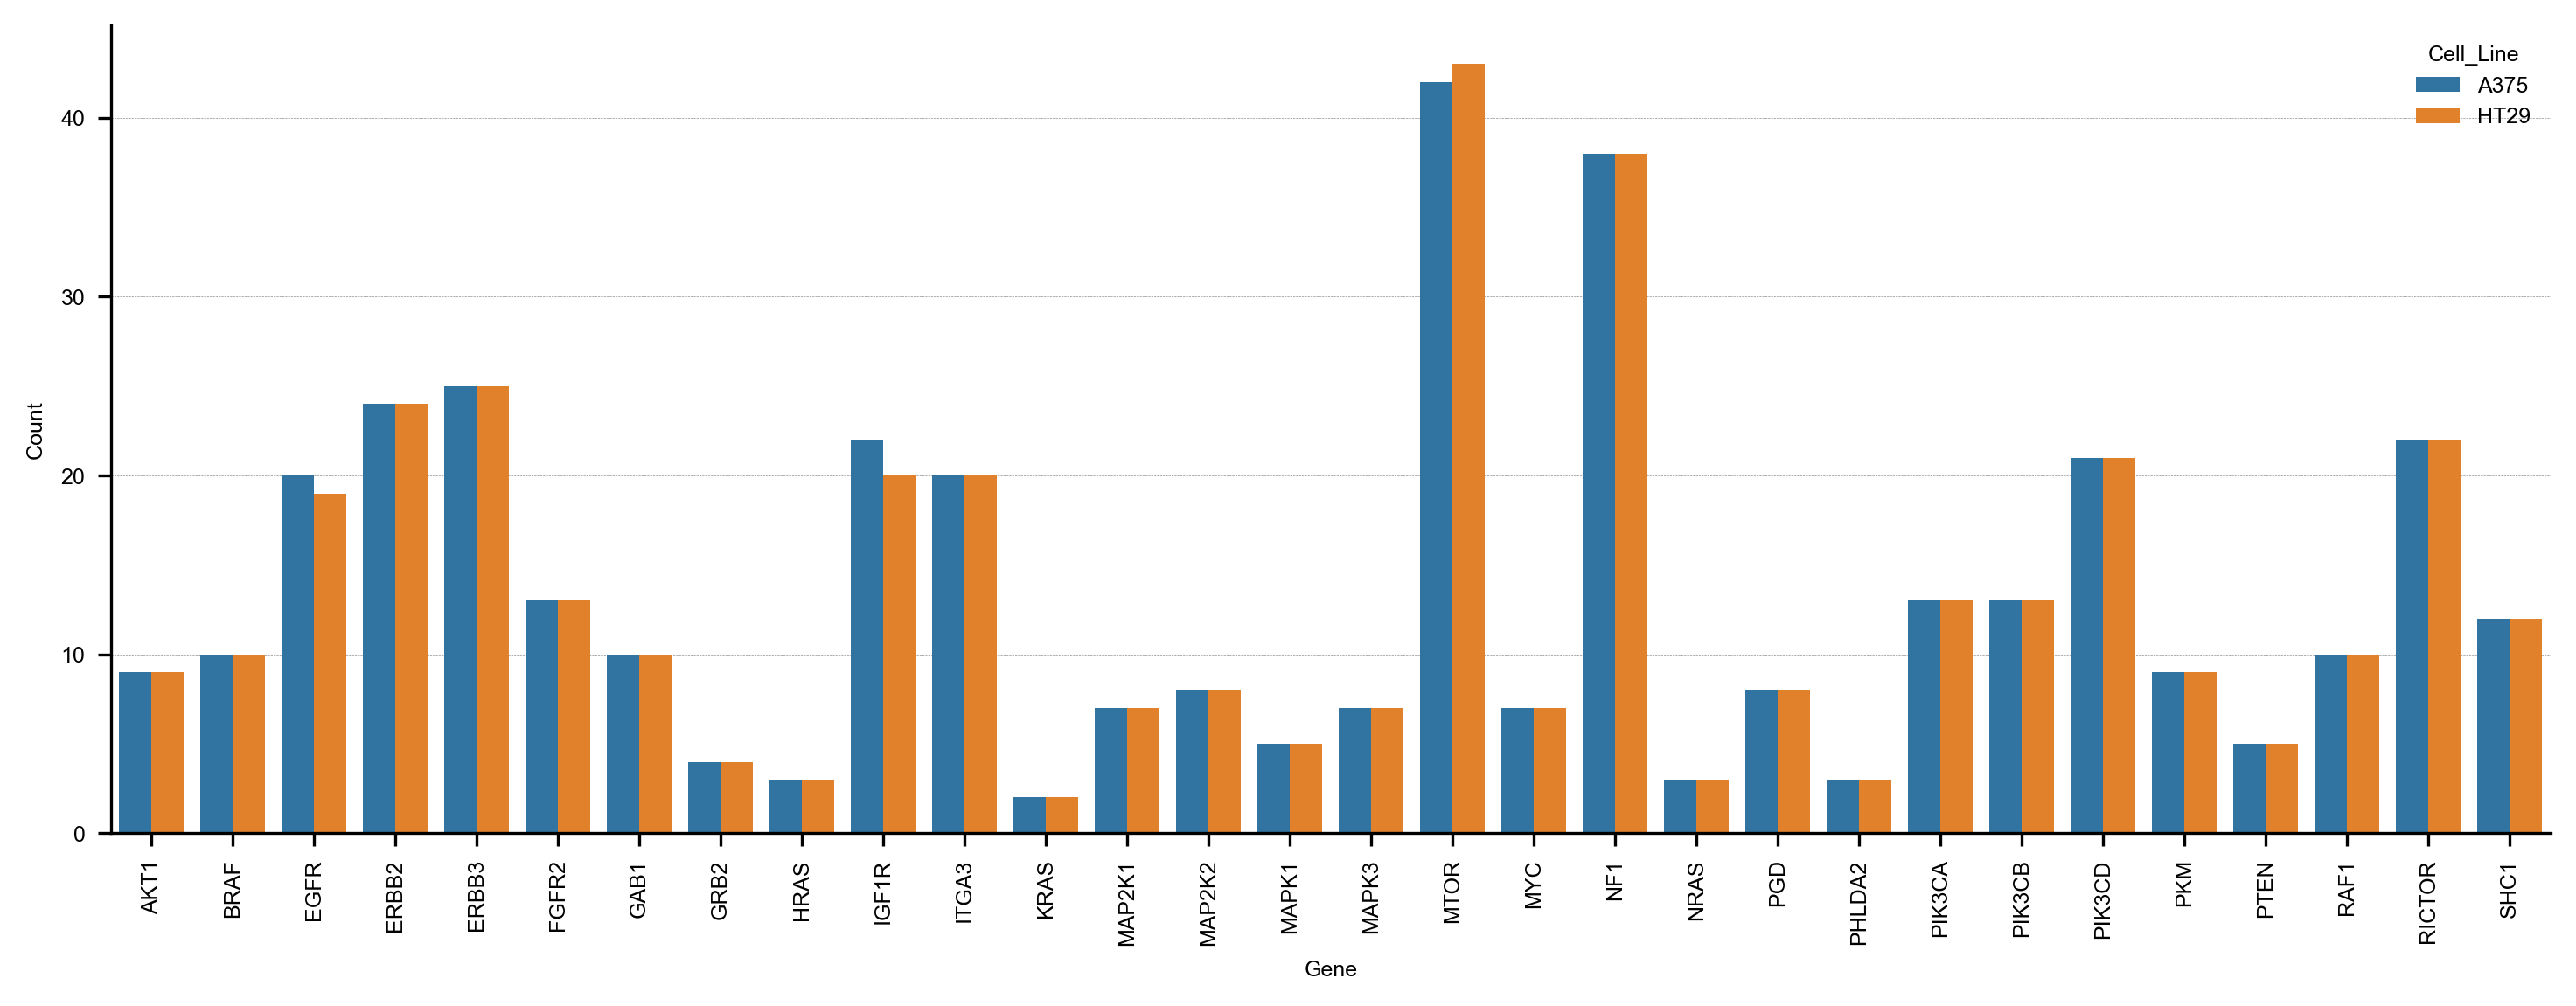

In [51]:
#Check distribution of non-hits after downsampling

counts_after_DS = (
    annotated_variants_df_balanced
    .groupby(["Cell_Line", "Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_after_DS = counts_after_DS[counts_after_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_after_DS,
    x="Gene", y="Count", hue="Cell_Line", errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [52]:
comparison_df = pd.DataFrame({
    'Before_Downsampling': annotated_variants_df['Class'].value_counts().sort_index(),
    'After_Downsampling': annotated_variants_df_balanced['Class'].value_counts().sort_index()
}).reset_index().rename(columns={'index': 'Class'})
comparison_df

,Class,Before_Downsampling,After_Downsampling
0,Neutral,82785,788
1,Resistance,788,788
2,Sensitivity,451,451


In [53]:
# Compute proportions within each group (Cell_Line × Gene)
prop_before = counts_non_hits_before_DS.copy()
prop_before["Proportion_before_DS"] = round(prop_before["Count"] / prop_before["Count"].sum(),4)
prop_before = prop_before[["Cell_Line", "Gene", "Proportion_before_DS"]]

prop_after = counts_non_hits_after_DS.copy()
prop_after["Proportion_after_DS"] = round(prop_after["Count"] / prop_after["Count"].sum(), 4)
prop_after = prop_after[["Cell_Line", "Gene", "Proportion_after_DS"]]


prop_compare = pd.merge(prop_before, prop_after,
                        on=["Cell_Line", "Gene"], how="inner")

# Correlation of proportions
corr = prop_compare["Proportion_before_DS"].corr(prop_compare["Proportion_after_DS"])

print("Correlation of per-group proportions (before vs after downsampling):", round(corr, 4))
print("\nProportion comparison (first 10 rows):")
print(prop_compare.head(10))

Correlation of per-group proportions (before vs after downsampling): 0.9996

Proportion comparison (first 10 rows):
  Cell_Line   Gene  Proportion_before_DS  Proportion_after_DS
0      A375   AKT1                0.0112               0.0114
1      A375   BRAF                0.0127               0.0127
2      A375   EGFR                0.0253               0.0254
3      A375  ERBB2                0.0305               0.0305
4      A375  ERBB3                0.0321               0.0317
5      A375  FGFR2                0.0162               0.0165
6      A375   GAB1                0.0123               0.0127
7      A375   GRB2                0.0052               0.0051
8      A375   HRAS                0.0043               0.0038
9      A375  IGF1R                0.0276               0.0279


# Modeling

In [54]:
#Define meta data columns to drop
meta_cols=[
    'Guide', 'Editor', 'Gene', 'Cell_Line', 'Drug', 'zscore', 'Source', 'Target Transcript ID', 'uniprot_accession',
    'RefSeq match transcript (MANE Select)', 'Amino Acid Edits', 'aa_change', 'pocket_id', 'Class'
]

In [21]:
#this functin will go on a .py file
def train_test_once(df, model, meta_cols, le, cv, stratified_downsampling, class_col, random_state_for_downsampling):

    #Perform stratified downsampling
    df_balanced = stratified_downsampling(df, class_col = class_col, random_state=random_state_for_downsampling)

    #Print class distribution after downsampling
    print("Class distribution after downsampling:")
    print(df_balanced['Class'].value_counts())

    #Separate train and test sets
    X = df_balanced.drop(columns=meta_cols + ["Class_encoded"])
    y = df_balanced["Class_encoded"]

    class_names = list(le.classes_)
    n_classes = len(class_names)

    fold_reports = []
    roc_auc_scores_weighted, roc_auc_scores_macro = [], []
    pr_auc_scores_weighted, pr_auc_scores_macro = [], []
    all_y_true, all_y_pred, all_probs = [], [], []
    shap_values_folds = []
    X_val_folds = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        probs = model.predict_proba(X_val) 

        #SHAP 
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_val)


        #Store predictions, true labels and probabilities 
        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)
        all_probs.extend(probs)

        #SHAP
        shap_values_folds.append(shap_vals)
        X_val_folds.append(X_val)

        #ROC AUC
        roc_auc_scores_weighted.append(roc_auc_score(y_val, probs, multi_class="ovr", average='weighted'))
        roc_auc_scores_macro.append(roc_auc_score(y_val, probs, multi_class="ovr", average='macro'))

        #PR AUC
        pr_auc_scores_weighted.append(average_precision_score(y_val, probs, average='weighted'))
        pr_auc_scores_macro.append(average_precision_score(y_val, probs, average='macro'))

        fold_reports.append(classification_report(y_val, y_pred, target_names=le.classes_, output_dict=True))


    # Aggregate metrics - average across folds 
    metrics = {}
    metrics["accuracy"] = np.mean([r["accuracy"] for r in fold_reports])

    for avg_key in ["macro avg", "weighted avg"]:
        metrics[f"precision_{avg_key}"] = np.mean([r[avg_key]["precision"] for r in fold_reports])
        metrics[f"recall_{avg_key}"] = np.mean([r[avg_key]["recall"] for r in fold_reports])
        metrics[f"f1_{avg_key}"] = np.mean([r[avg_key]["f1-score"] for r in fold_reports])

    for cname in class_names:
        metrics[f"precision_{cname}"] = np.mean([r[cname]["precision"] for r in fold_reports])
        metrics[f"recall_{cname}"] = np.mean([r[cname]["recall"]    for r in fold_reports])
        metrics[f"f1_{cname}"] = np.mean([r[cname]["f1-score"]  for r in fold_reports])

    metrics["roc_auc_weighted"] = np.mean(roc_auc_scores_weighted)
    metrics["roc_auc_macro"] = np.mean(roc_auc_scores_macro)
    metrics["pr_auc_weighted"] = np.mean(pr_auc_scores_weighted)
    metrics["pr_auc_macro"] = np.mean(pr_auc_scores_macro)

    cm = confusion_matrix(all_y_true, all_y_pred, labels=np.arange(len(le.classes_)))
    return metrics, cm, np.array(all_y_true), np.array(all_probs), shap_values_folds, X_val_folds

### Define Model and Cross-Validation

In [22]:
xgb_classifier_optimized = XGBClassifier(
    subsample=0.9877774683819198,
    reg_lambda=0.3899556856475762,
    reg_alpha=0.9786681196496283,
    n_estimators=785,
    min_child_weight=1,
    max_depth=6,
    learning_rate=0.08044384262565375,
    colsample_bytree=0.5615430106531324,
    gamma = 0.6485650981237915,
    objective="multi:softprob",   
    num_class=len(le.classes_),   
    random_state=1,
    n_jobs=-1                    
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Run Model

In [26]:
# Run multiple times to get average performance across different downsamplings
n_runs = 10
all_metrics, all_cms = [], []
all_y_true_runs, all_probs_runs = [], []
all_shap_values_runs, all_X_val_runs = [], []

for i in range(n_runs):
    print(f"\n--- Run {i+1}/{n_runs} ---")
    metrics, cm, y_true, probs, shap_values_folds, X_val_folds = train_test_once(
        df=annotated_variants_df,
        model=xgb_classifier_optimized,
        meta_cols=meta_cols,
        le=le,
        cv=skf,
        stratified_downsampling=stratified_downsampling,
        class_col='Class',
        random_state_for_downsampling=i
    )
    all_metrics.append(metrics)
    all_cms.append(cm)
    all_y_true_runs.append(y_true)
    all_probs_runs.append(probs)
    print("Metrics:", metrics)
    print("Confusion Matrix:\n", cm)

    #SHAP
    #.extend because i don't need run level separation here
    all_shap_values_runs.extend(shap_values_folds)
    all_X_val_runs.extend(X_val_folds)

# === Aggregate metrics across runs ===
metrics_df = pd.DataFrame(all_metrics)
metrics_mean = metrics_df.mean()
metrics_std = metrics_df.std()

cm_mean = np.mean(np.array(all_cms, dtype=float), axis=0)
cm_std  = np.std(np.array(all_cms, dtype=float), axis=0)

# Reorder confusion matrix
desired_order = ["Sensitivity", "Neutral", "Resistance"]

# Map to label encoder indices
reorder_idx = [list(le.classes_).index(c) for c in desired_order]

# Reorder rows and columns
cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

# Update class_names for correct axis labels
class_names_reordered = desired_order

print("=== Mean metrics ===")
print(metrics_mean)
print("\n=== Std metrics ===")
print(metrics_std)

print("\n=== Mean confusion matrix ===")
print(cm_mean)
print("\n=== Std confusion matrix ===")
print(cm_std)


--- Run 1/10 ---
Class distribution after downsampling:
Class
Neutral        788
Resistance     788
Sensitivity    451
Name: count, dtype: int64
Metrics: {'accuracy': np.float64(0.7020203125950253), 'precision_macro avg': np.float64(0.7080230353183458), 'recall_macro avg': np.float64(0.6898208007036516), 'f1_macro avg': np.float64(0.6964154533989694), 'precision_weighted avg': np.float64(0.7052460731638313), 'recall_weighted avg': np.float64(0.7020203125950253), 'f1_weighted avg': np.float64(0.7015088396983886), 'precision_Neutral': np.float64(0.6672506842921967), 'recall_Neutral': np.float64(0.7423607191808432), 'f1_Neutral': np.float64(0.7027069363542466), 'precision_Resistance': np.float64(0.731949219983626), 'recall_Resistance': np.float64(0.7106425864710151), 'f1_Resistance': np.float64(0.7206951455516104), 'precision_Sensitivity': np.float64(0.7248692016792145), 'recall_Sensitivity': np.float64(0.6164590964590965), 'f1_Sensitivity': np.float64(0.6658442782910512), 'roc_auc_weigh

### Get Metrics

In [27]:
def summarize_results(metrics_list, cms, class_names):
    """
    Summarize metrics (global + class-wise) and confusion matrices across runs.

    Parameters
    ----------
    metrics_list : list of dict
        Each element is the metrics dict returned from train_test_once.
    cms : list of np.ndarray
        Confusion matrices (one per run).
    class_names : list
        Names of classes for the confusion matrix.
    """

    # === Metrics summary ===
    metrics_keys = metrics_list[0].keys()
    summary = {}
    for key in metrics_keys:
        values = np.array([m[key] for m in metrics_list])
        summary[key] = (np.mean(values), np.std(values))

    print("\n=== Metrics Summary (mean ± std) ===")

    # Global averages
    for k in ["accuracy", "roc_auc_weighted", "roc_auc_macro",
              "pr_auc_weighted", "pr_auc_macro"]:
        mean, std = summary[k]
        print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Macro/weighted averages
    for k in ["precision_macro avg", "recall_macro avg", "f1_macro avg",
              "precision_weighted avg", "recall_weighted avg", "f1_weighted avg"]:
        if k in summary:
            mean, std = summary[k]
            print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Class-wise metrics
    print("\n=== Class-wise Metrics (mean ± std) ===")
    for cname in class_names:
        for metric in ["precision", "recall", "f1"]:
            key = f"{metric}_{cname}"
            if key in summary:
                mean, std = summary[key]
                print(f"{cname:10s} {metric:10s}: {mean:.3f} ± {std:.3f}")

   # === Confusion Matrix summary ===
    cm_array = np.stack(cms)
    cm_mean = np.mean(cm_array, axis=0)
    cm_std = np.std(cm_array, axis=0)

    # === Reorder ===
    desired_order = ["Sensitivity", "Neutral", "Resistance"]
    reorder_idx = [list(class_names).index(c) for c in desired_order]

    cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
    cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

    class_names = desired_order

    # Combined annotated version
    combined = np.empty(cm_mean.shape, dtype=object)
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            mean_val = int(round(cm_mean[i, j]))   
            std_val = int(cm_std[i, j])       
            combined[i, j] = f"{mean_val}±{std_val}"


    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_mean, annot=combined, fmt="", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 8})
    #plt.title("Confusion Matrix (mean ± std)")
    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8)
    plt.xlabel("Predicted Label", fontsize=9)
    plt.ylabel("True Label", fontsize=9)
    plt.show()

# === Bar plot: Precision & Recall per class (mean ± std) ===
    precision_means = [summary[f"precision_{c}"][0] for c in class_names]
    precision_stds  = [summary[f"precision_{c}"][1] for c in class_names]
    recall_means    = [summary[f"recall_{c}"][0] for c in class_names]
    recall_stds     = [summary[f"recall_{c}"][1] for c in class_names]

    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(6, 5))
    bars1 = plt.bar(x - width/2, precision_means, width,
                    yerr=precision_stds, capsize=3,
                    label="Precision", color="lightsteelblue")
    bars2 = plt.bar(x + width/2, recall_means, width,
                    yerr=recall_stds, capsize=3,
                    label="Recall", color="midnightblue")

    # Add numbers on top
    for bar in bars1:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.03,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.03,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)

    plt.xticks(x, class_names, fontsize=8)
    plt.ylabel("Score", fontsize=10)
    plt.ylim(0, 1.05)
    plt.legend(loc="upper right", fontsize=6)
    plt.show()

    return summary, cm_mean, cm_std


=== Metrics Summary (mean ± std) ===
accuracy            : 0.702 ± 0.005
roc_auc_weighted    : 0.844 ± 0.003
roc_auc_macro       : 0.847 ± 0.003
pr_auc_weighted     : 0.761 ± 0.005
pr_auc_macro        : 0.757 ± 0.005
precision_macro avg : 0.710 ± 0.006
recall_macro avg    : 0.690 ± 0.005
f1_macro avg        : 0.697 ± 0.005
precision_weighted avg: 0.706 ± 0.006
recall_weighted avg : 0.702 ± 0.005
f1_weighted avg     : 0.701 ± 0.005

=== Class-wise Metrics (mean ± std) ===
Neutral    precision : 0.667 ± 0.006
Neutral    recall    : 0.754 ± 0.010
Neutral    f1        : 0.707 ± 0.008
Resistance precision : 0.731 ± 0.008
Resistance recall    : 0.700 ± 0.005
Resistance f1        : 0.715 ± 0.005
Sensitivity precision : 0.731 ± 0.015
Sensitivity recall    : 0.616 ± 0.006
Sensitivity f1        : 0.667 ± 0.009


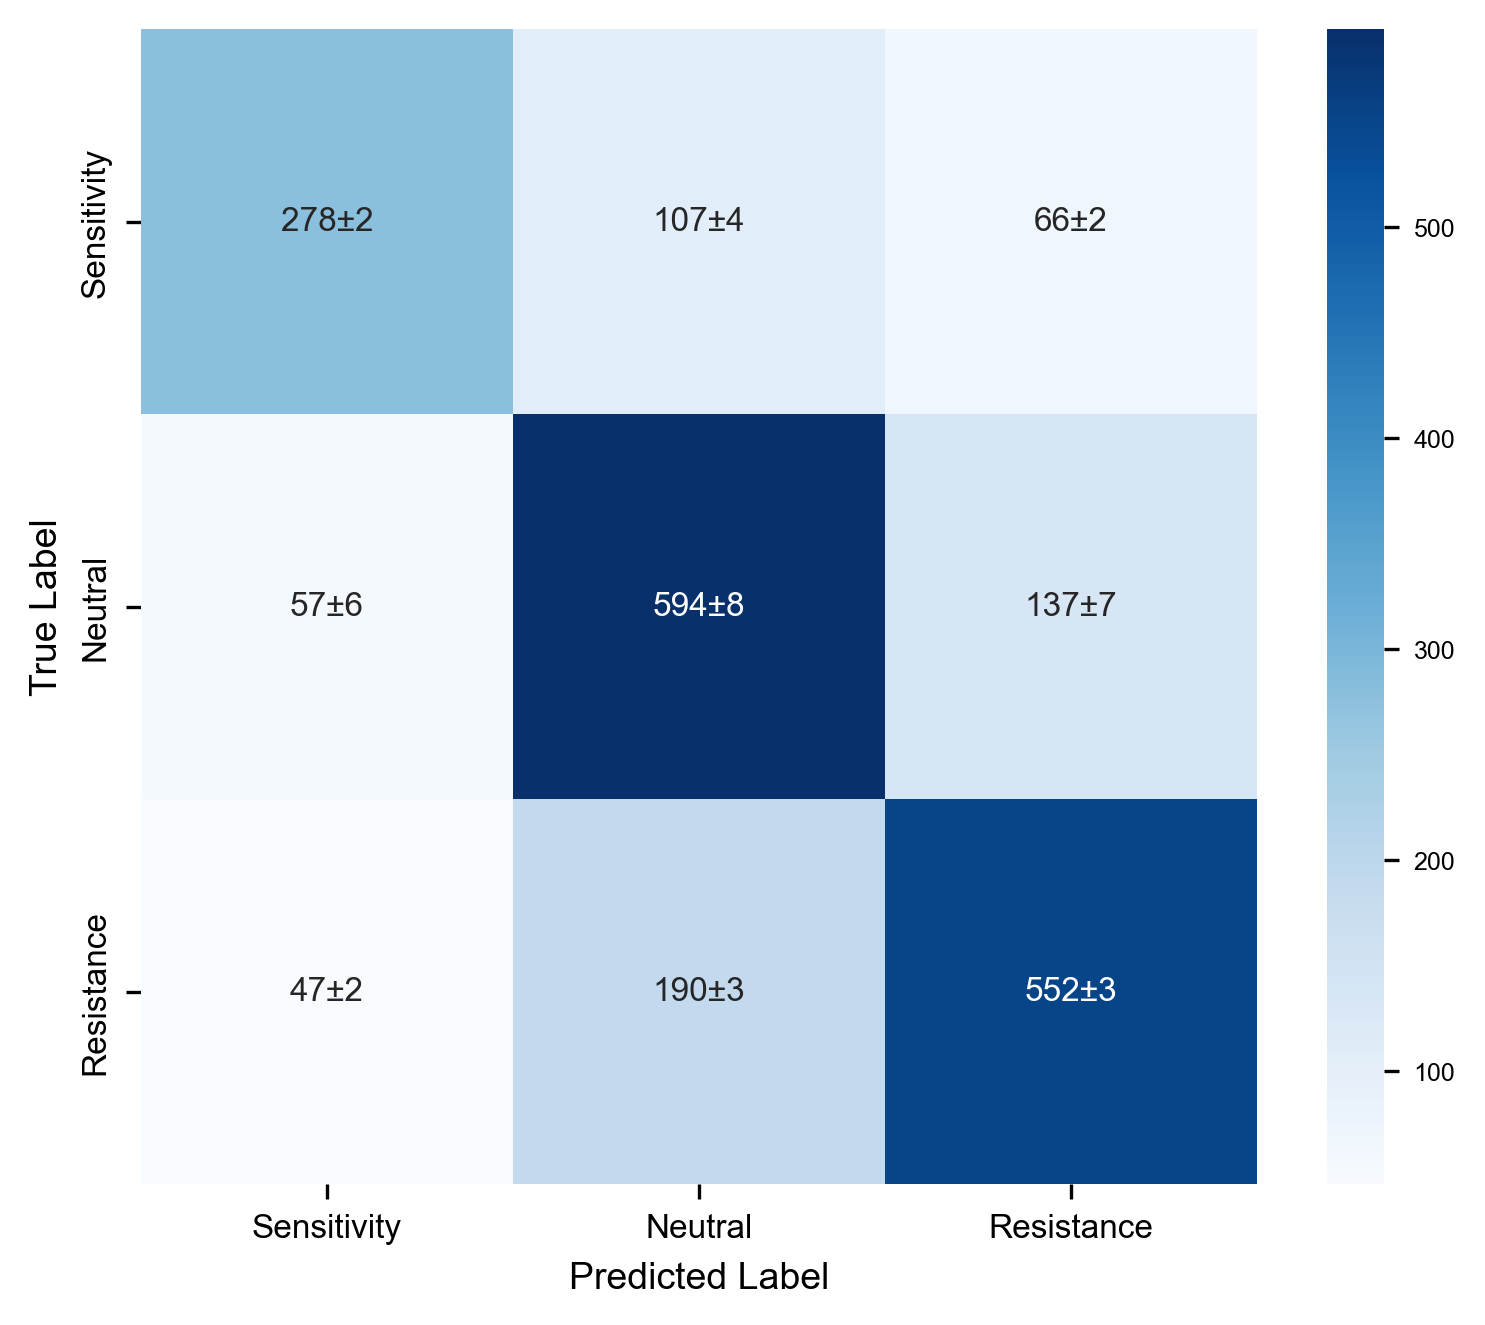

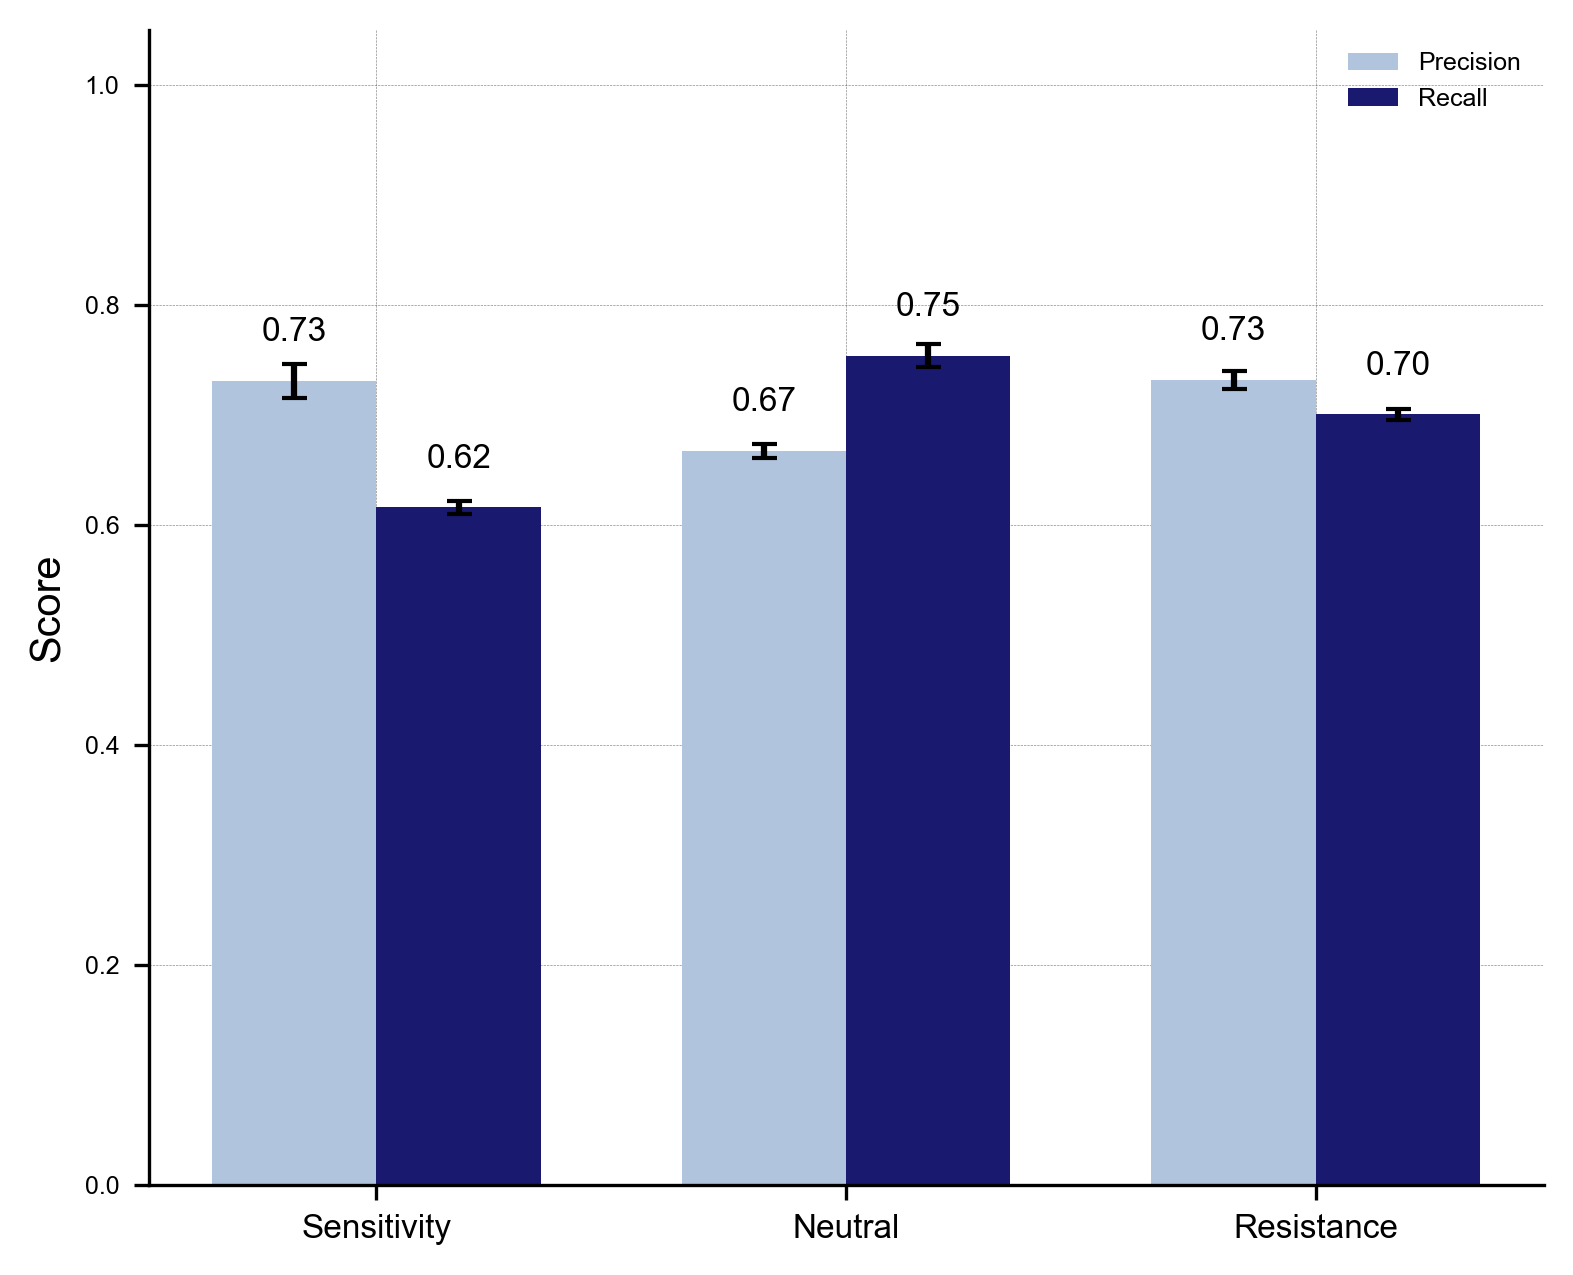

In [28]:
metrics_summary, cm_mean, cm_std = summarize_results(all_metrics, all_cms,
                                                     class_names=le.classes_)

### F1 plot per class

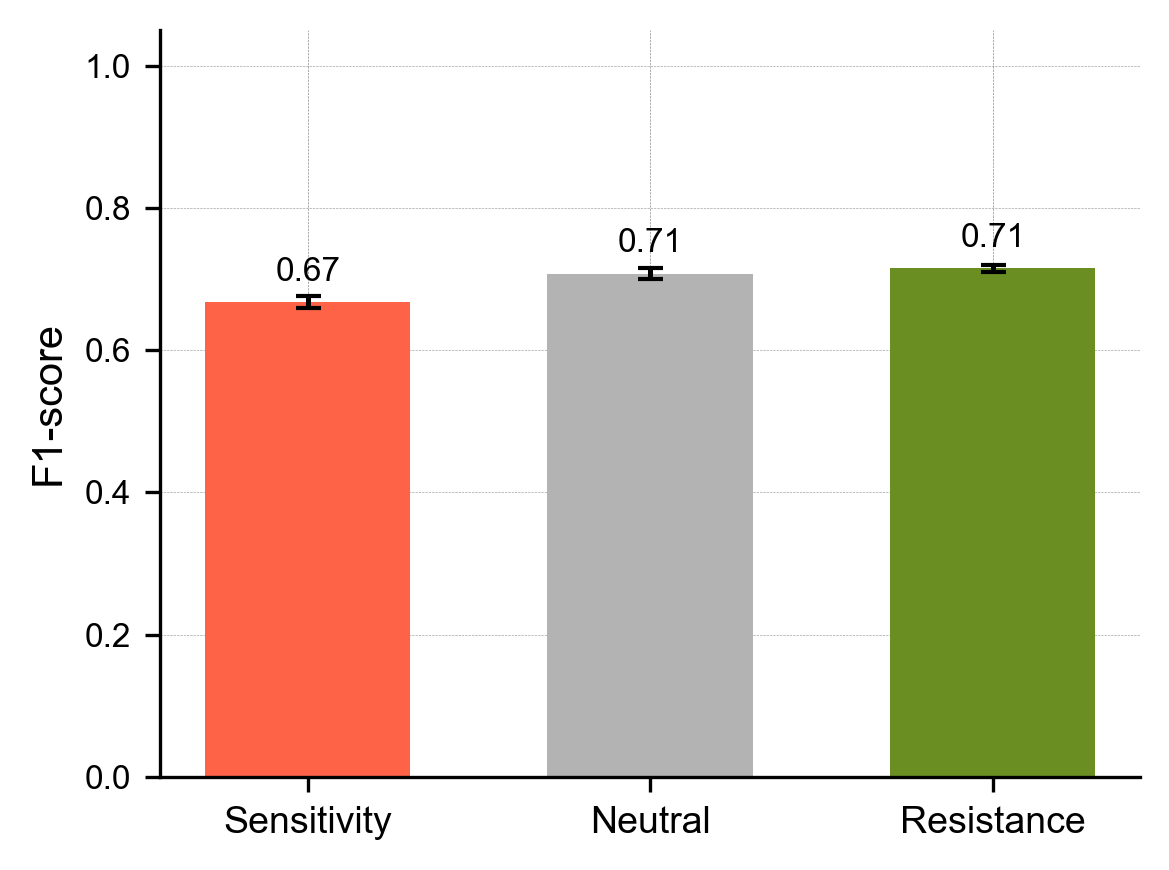

In [29]:
# Define your desired class order
class_order = ["Sensitivity", "Neutral", "Resistance"]

# Compute mean and std in that order
f1_means = [np.mean([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]
f1_stds  = [np.std([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]

# Define consistent colors for each class
colors_bar = ["tomato", "#b3b3b3", "olivedrab"]

x = np.arange(len(class_order))
plt.figure(figsize=(4,3))

bars = plt.bar(x, f1_means, yerr=f1_stds, capsize=3, color=colors_bar, width = 0.6, error_kw=dict(ecolor='black', lw=1.2))

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center', va='bottom', fontsize=8)

plt.xticks(x, class_order, fontsize=9)
plt.ylabel("F1-score", fontsize=10)
plt.yticks(fontsize=8)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
#Save the dataset used for the F1 plot
f1_results_to_plot_df = pd.DataFrame({
    "Class": class_order,
    "F1_mean": f1_means,
    "F1_std": f1_stds
})

f1_results_to_plot_df.to_csv("/Users/carolinapinto/desktop/Tese/f1_scores_across_10_runs_plot.csv", index=False)

### PR Curve

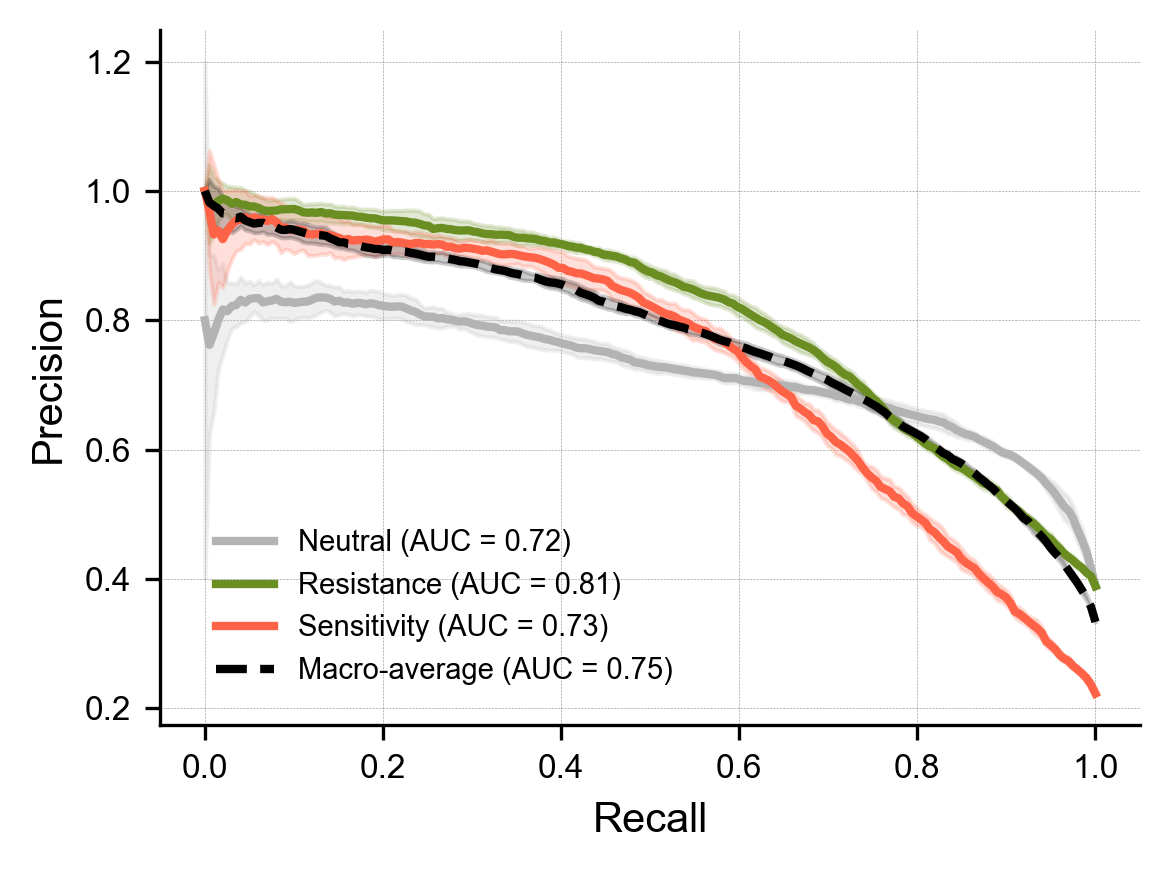

In [30]:
classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

plt.figure(figsize=(4,3))

for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    plt.plot(recall_grid, mean_precision, color=colors[i], lw=2, label=f"{class_name} (AUC = {mean_auc:.2f})")
    plt.fill_between(recall_grid, mean_precision - std_precision, mean_precision + std_precision,
                     color=colors[i], alpha=0.2)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)


plt.plot(recall_grid, mean_macro, color='black', lw=2, linestyle='--', label=f"Macro-average (AUC = {mean_auc_macro:.2f})")
plt.fill_between(recall_grid, mean_macro - std_macro, mean_macro + std_macro, color='black', alpha=0.2)

plt.xlabel("Recall", fontsize=10)
plt.xticks(fontsize=8)
plt.ylabel("Precision", fontsize=10)
plt.yticks(fontsize=8)
plt.legend(fontsize=7, loc="lower left", frameon=False, bbox_to_anchor=(0.03, 0.02))
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
#Save PR curve data for reproducibility
classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

#Store all PR curves data 
all_pr_dfs = []
for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    #Dataframe with the per-class PR curve data for reproducibility
    df_class = pd.DataFrame({
        "Recall": recall_grid,
        "Mean_Precision": mean_precision,
        "Std_Precision": std_precision,
        "Class": class_name,
        "Mean_AUC": mean_auc,
        "Std_AUC": std_auc
    })
    all_pr_dfs.append(df_class)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)

df_macro = pd.DataFrame({
    "Recall": recall_grid,
    "Mean_Precision": mean_macro,
    "Std_Precision": std_macro,
    "Class": "Macro-average",
    "Mean_AUC": mean_auc_macro,
    "Std_AUC": std_auc_macro
})
all_pr_dfs.append(df_macro)

#Combine all into a single dataframe
pr_curve_data_df = pd.concat(all_pr_dfs, ignore_index=True)
pr_curve_data_df.to_csv("/Users/carolinapinto/desktop/Tese/pr_curve_data_across_10_runs_plot.csv", index=False)

## SHAP

In [31]:
def get_stacked_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class):
    """
    Stack SHAP values and corresponding feature matrices across
    all CV folds and runs for a given class.
    """
    # Get class index
    class_idx = list(le.classes_).index(target_class)

    shap_blocks = []
    X_blocks = []

    for fold_shap, X_val in zip(all_shap_values_runs, all_X_val_runs):
        # fold_shap shape: (n_samples, n_features, n_classes)
        shap_blocks.append(fold_shap[:, :, class_idx])
        X_blocks.append(X_val)

    shap_c = np.vstack(shap_blocks)
    X_c = pd.concat(X_blocks, axis=0)

    assert shap_c.shape[0] == X_c.shape[0], "Row mismatch after stacking"

    return shap_c, X_c


def top_k_features_by_mean_abs_shap(shap_c, X_c, k=10):
    mean_abs = np.mean(np.abs(shap_c), axis=0)
    s = pd.Series(mean_abs, index=X_c.columns).sort_values(ascending=False)
    return s.head(k)  # returns a Series: index=feature, value=mean|SHAP|


def plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class, k=10):
    shap_c, X_c = get_stacked_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class)

    topk = top_k_features_by_mean_abs_shap(shap_c, X_c, k=k)
    top_features = topk.index.tolist()

    # Subset to top-k features
    cols_idx = [X_c.columns.get_loc(f) for f in top_features]
    shap_top = shap_c[:, cols_idx]
    X_top = X_c[top_features]

    print(f"\n=== {target_class}: Top {k} by mean(|SHAP|) ===")
    print(topk)

    # Bar: mean absolute SHAP
    shap.summary_plot(shap_top, X_top, plot_type="bar", max_display=k)

    # Beeswarm: distribution + direction
    shap.summary_plot(shap_top, X_top, max_display=k)



=== Sensitivity: Top 10 by mean(|SHAP|) ===
CRISPR_essentiality_score    0.284934
lnIC50                       0.278489
protein_abundance_zscore     0.174480
Gene_expression_voom         0.129782
LOEUF                        0.086549
CADD_PHRED                   0.067250
DANN_score                   0.035010
SpliceAI_pred_DP_DL          0.031969
SpliceAI_pred_DP_DG          0.028682
PolyPhen_pathogenicity       0.028073
dtype: float32


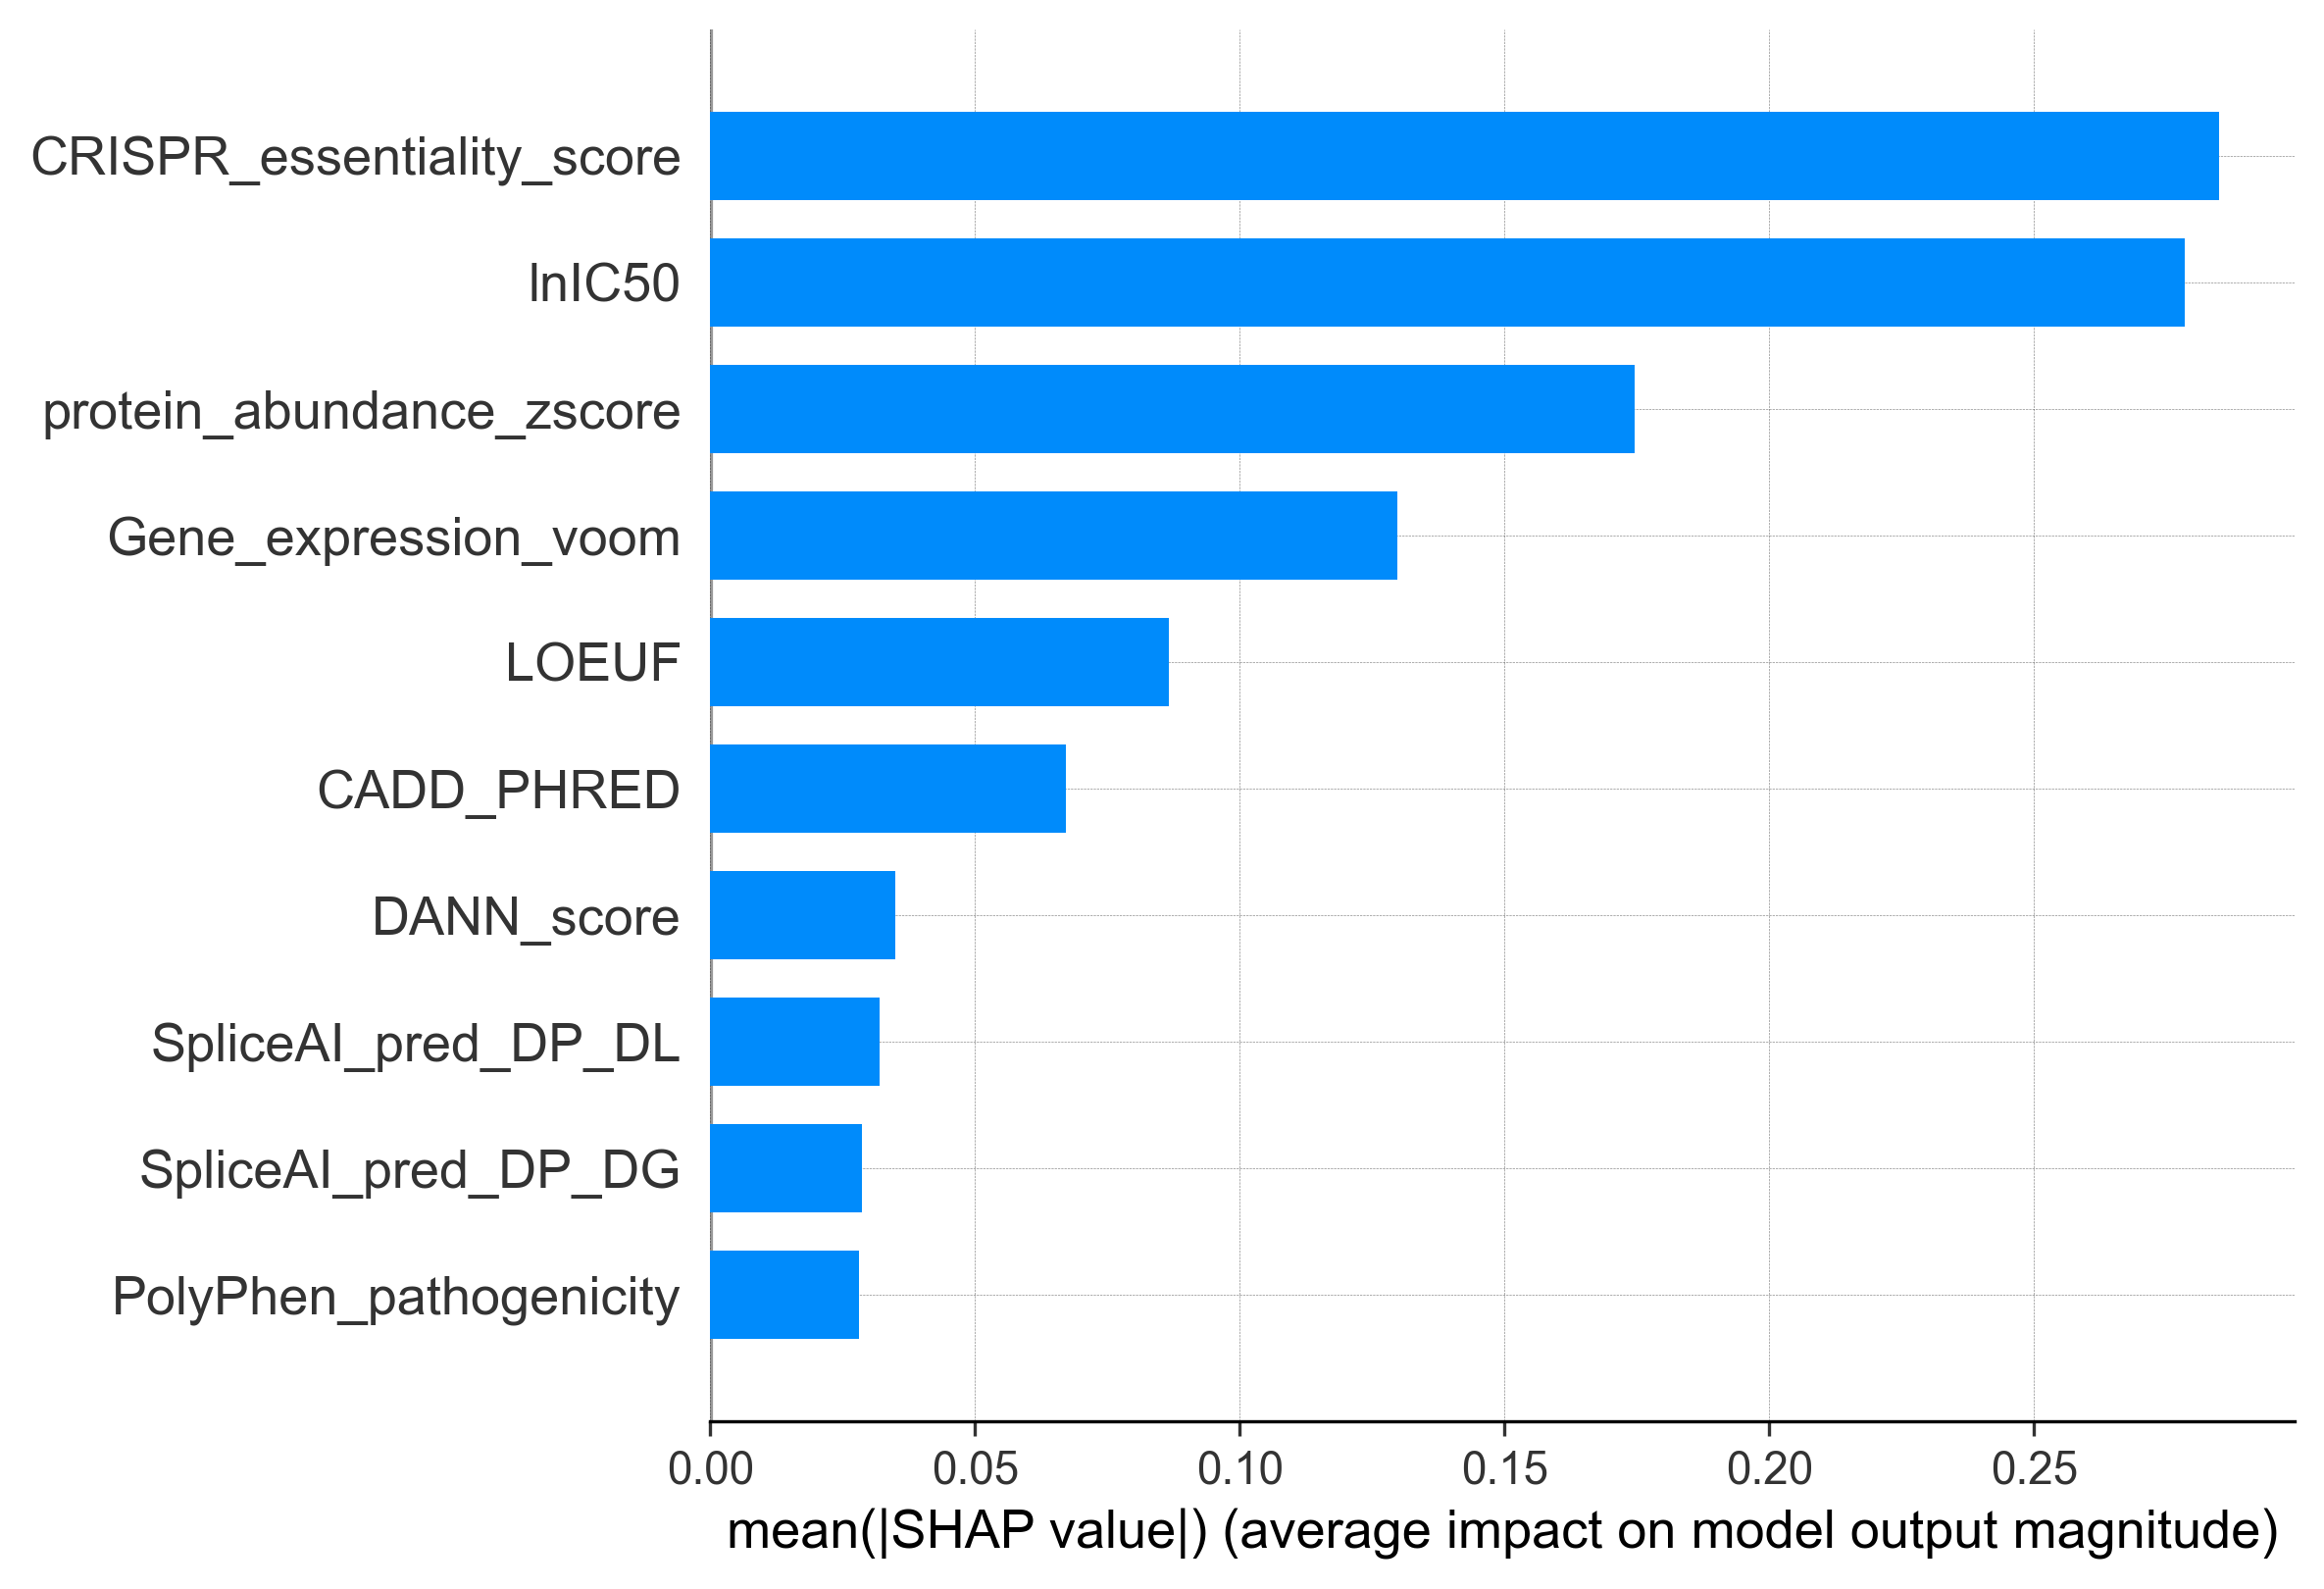

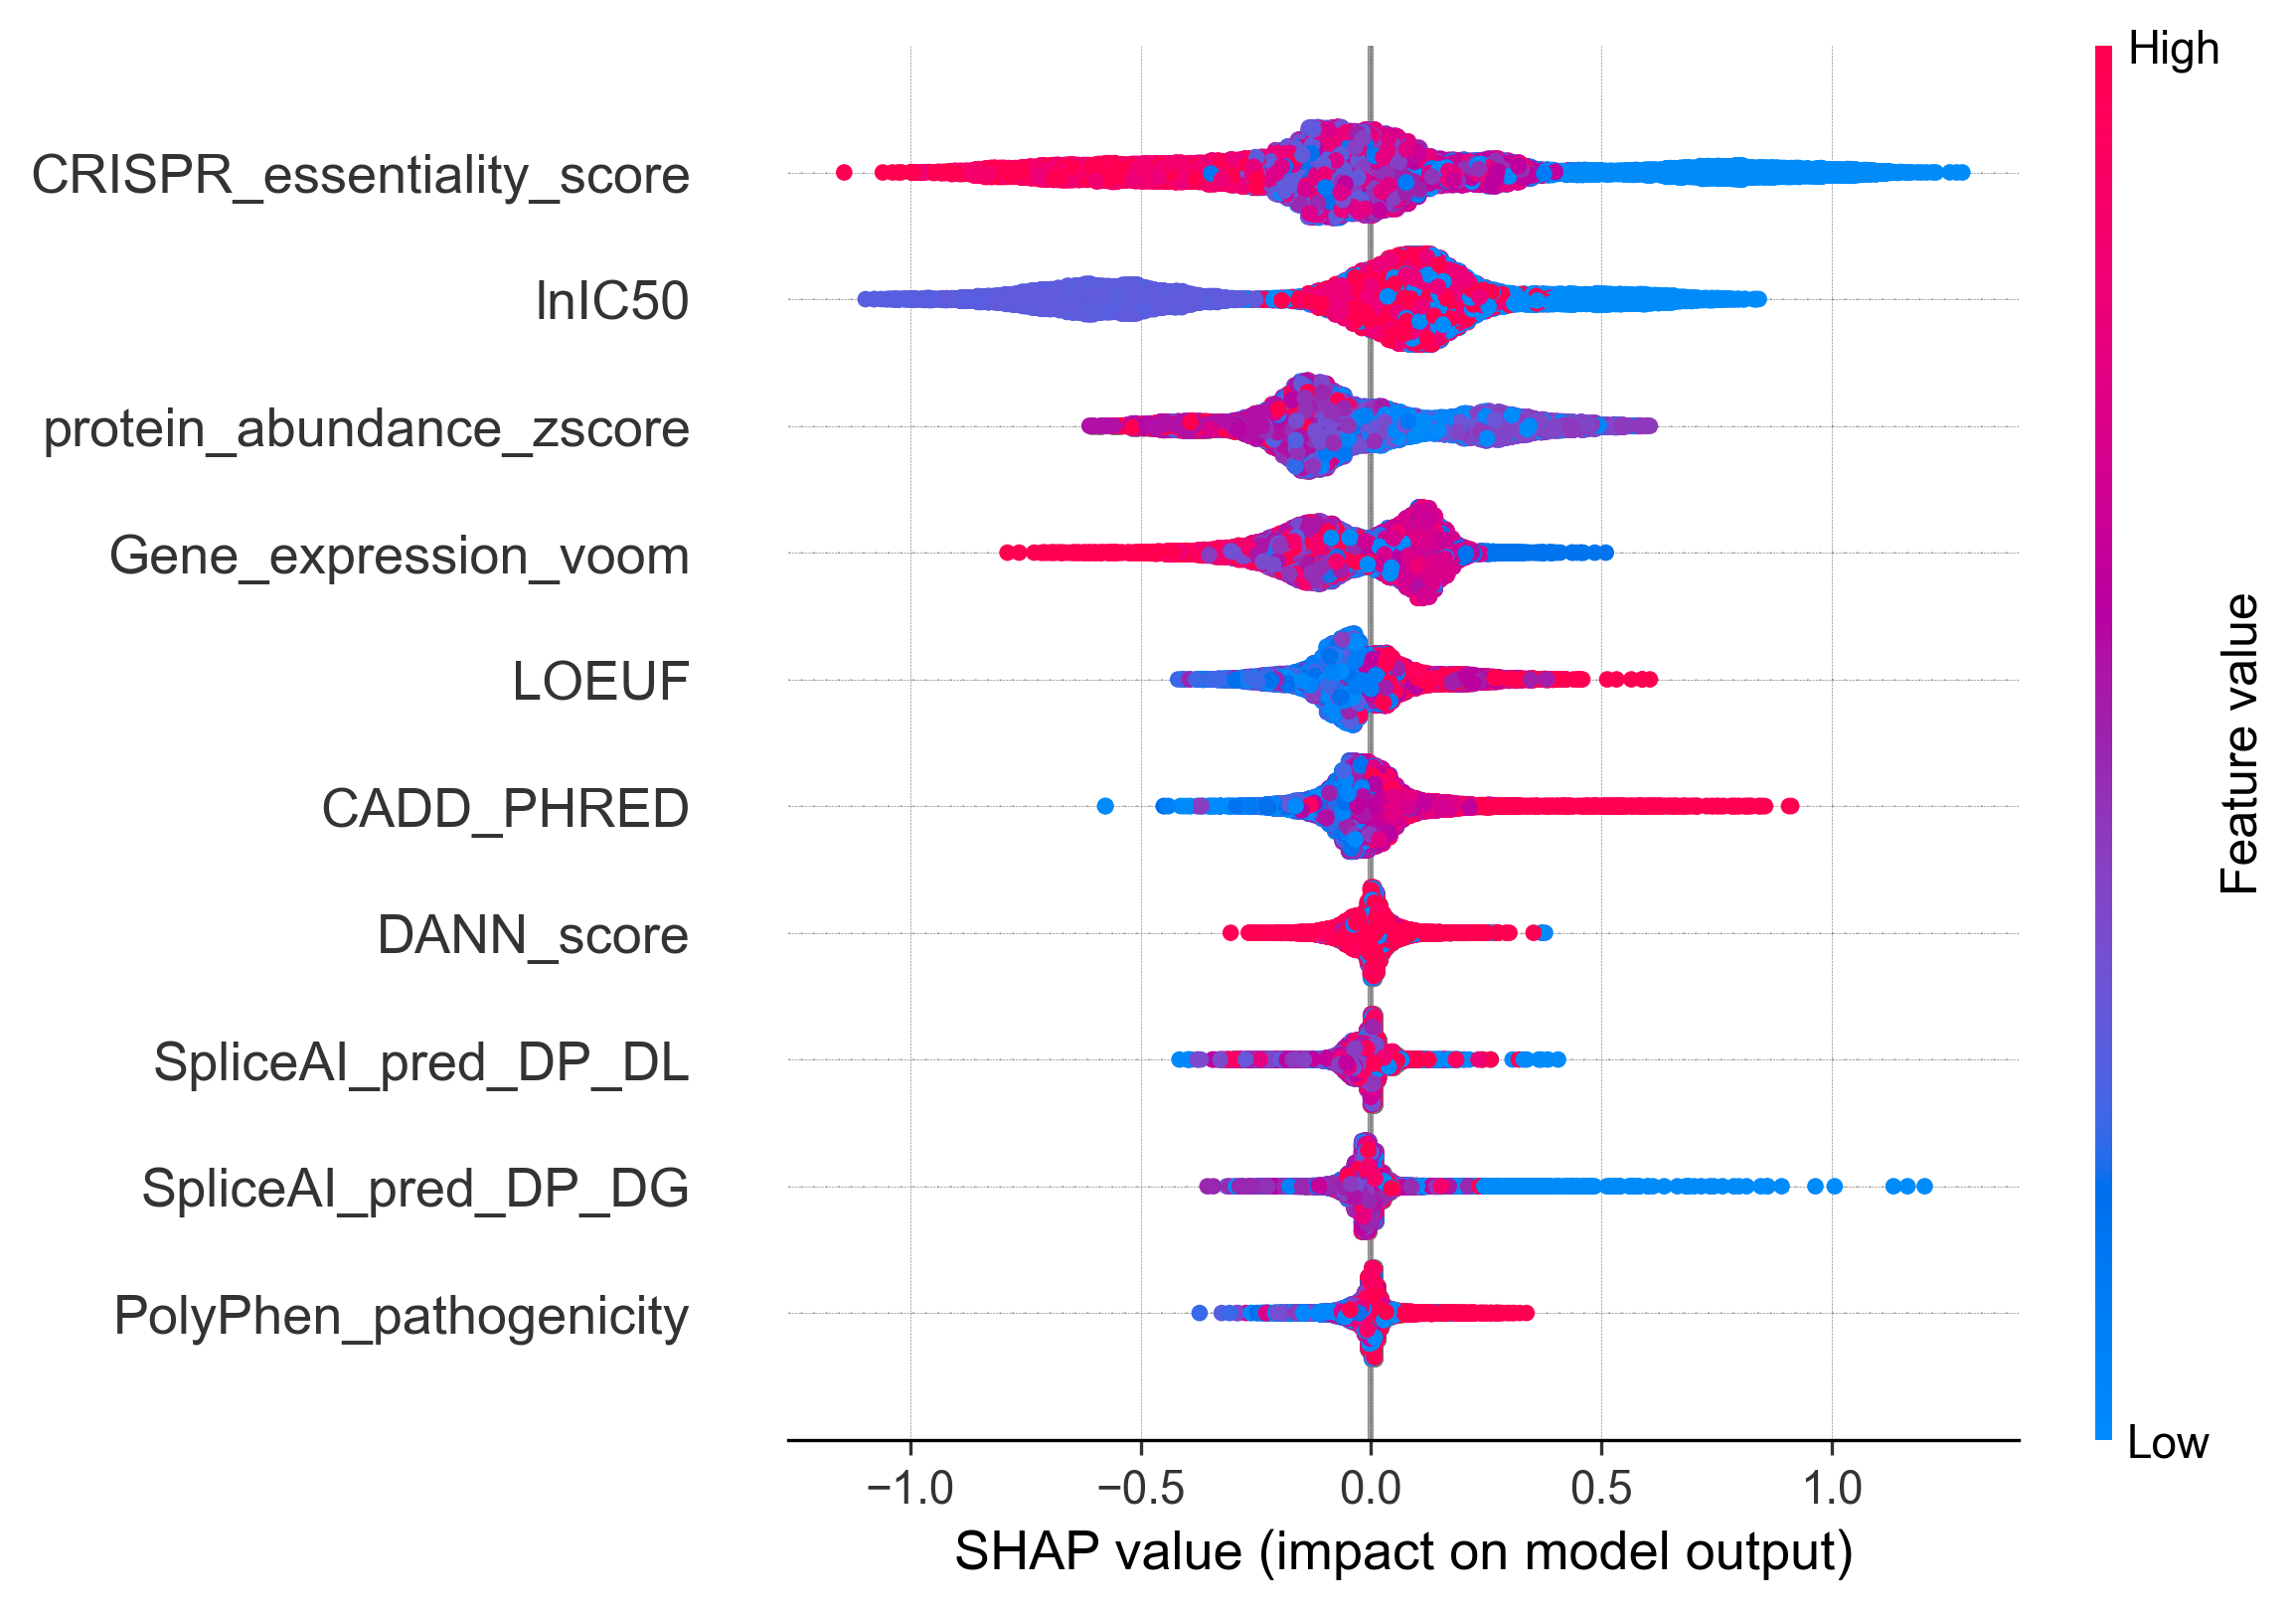

In [32]:
plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class='Sensitivity', k=10)


=== Neutral: Top 10 by mean(|SHAP|) ===
CADD_PHRED                   0.229923
lnIC50                       0.228182
CRISPR_essentiality_score    0.182006
BayesDel_noAF_score          0.059144
protein_abundance_zscore     0.049651
AlphaMissense_score          0.044414
VARITY_R_LOO_score           0.040755
ClinPred                     0.039169
drug_target_gene_distance    0.032831
MetaRNN_score                0.029806
dtype: float32


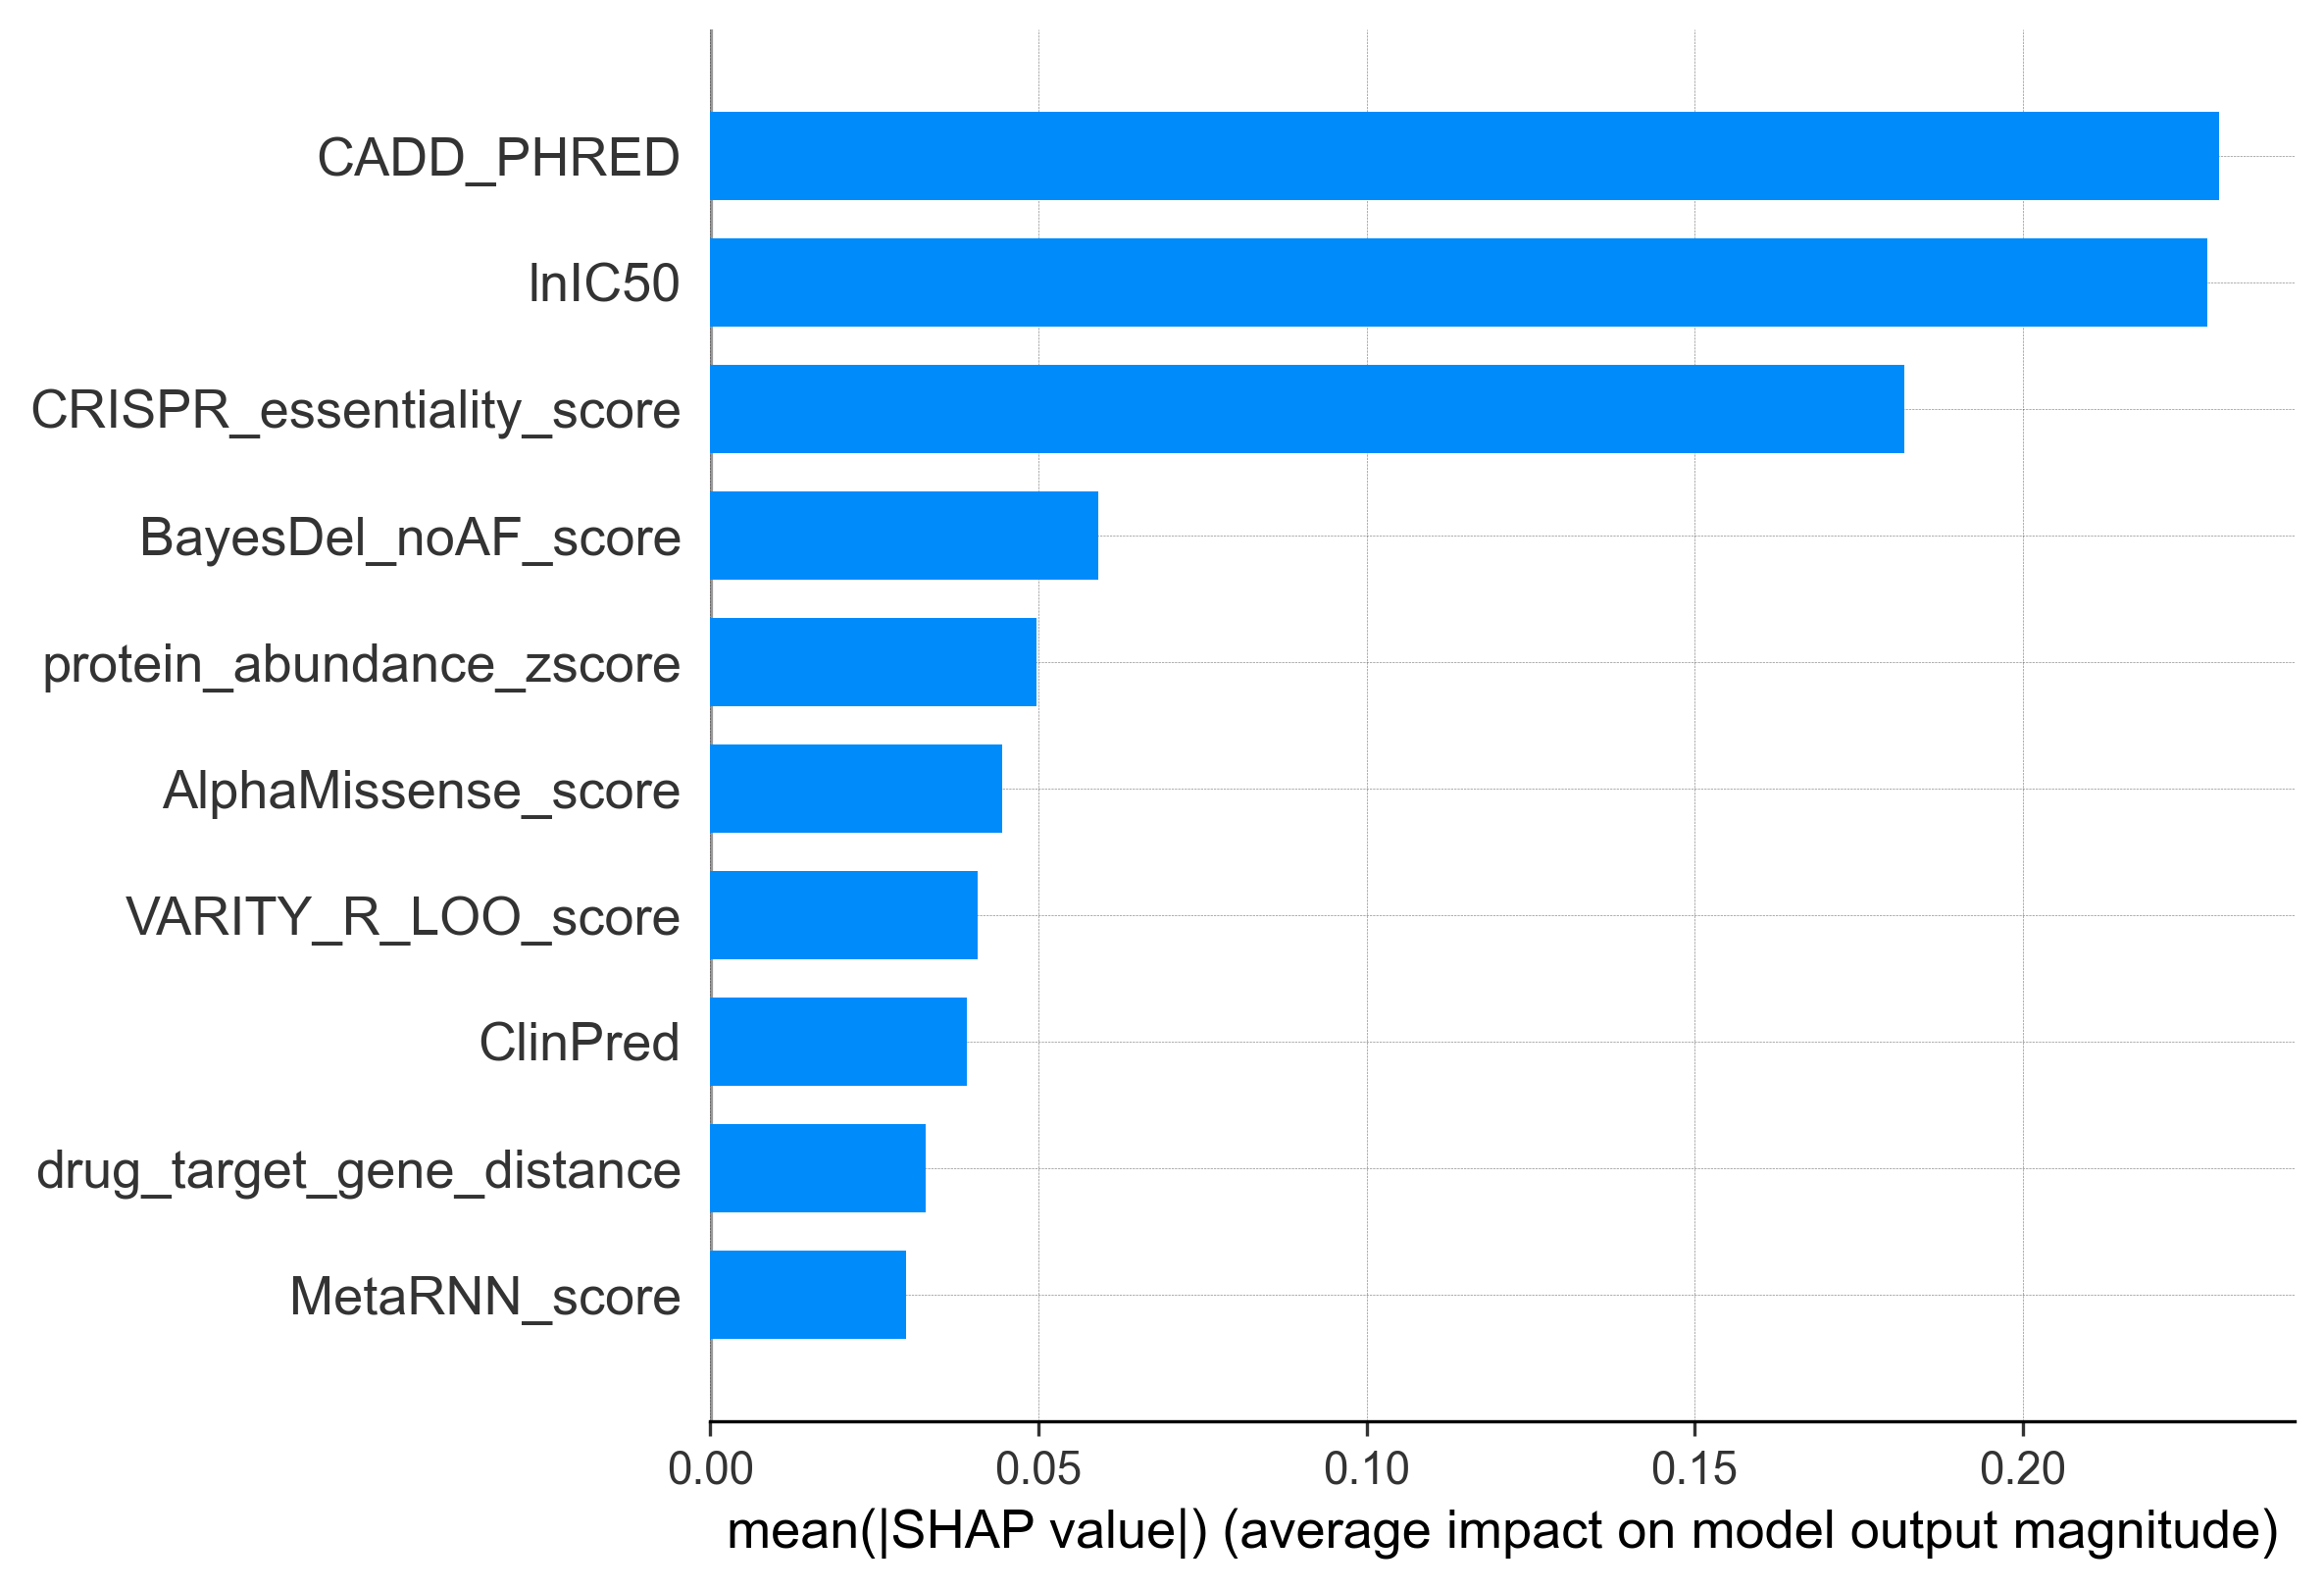

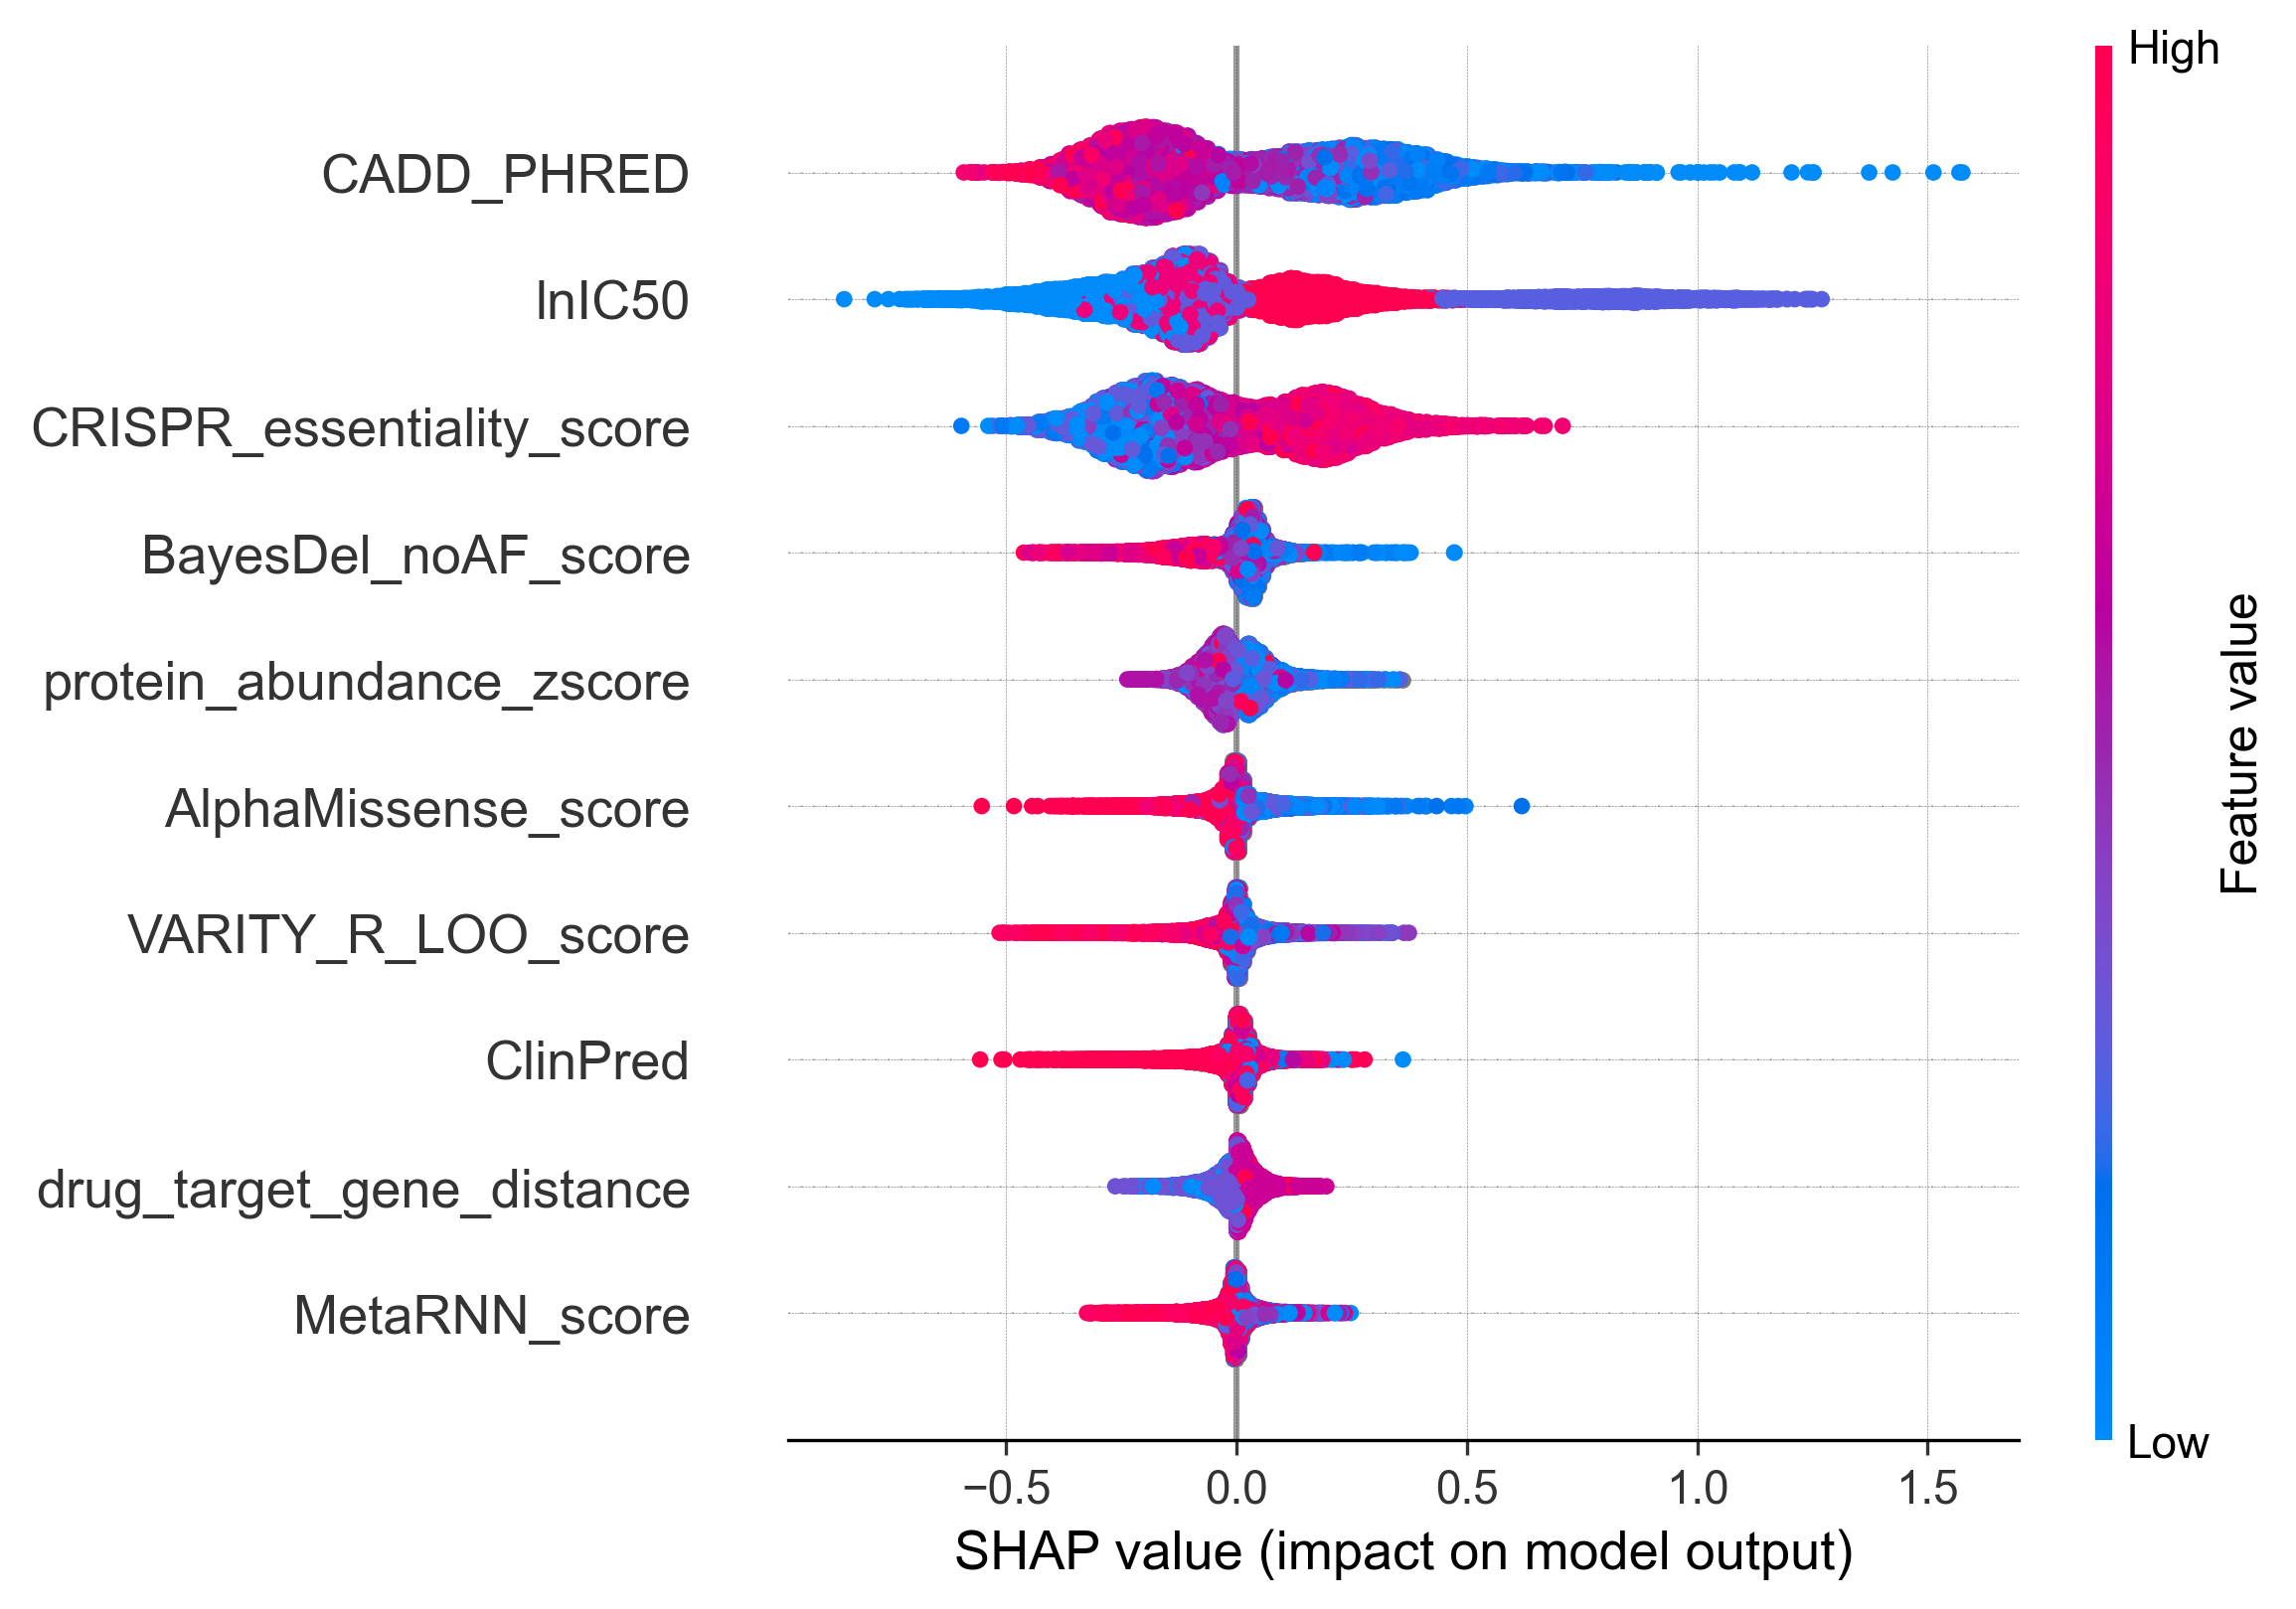

In [33]:
plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class='Neutral', k=10)


=== Resistance: Top 10 by mean(|SHAP|) ===
lnIC50                       0.190047
protein_abundance_zscore     0.159389
gene_cn_total                0.114200
CRISPR_essentiality_score    0.082497
Gene_expression_voom         0.081948
ClinPred                     0.059335
VARITY_R_LOO_score           0.054741
LOEUF                        0.049993
CADD_PHRED                   0.039289
GERP++_NR                    0.038987
dtype: float32


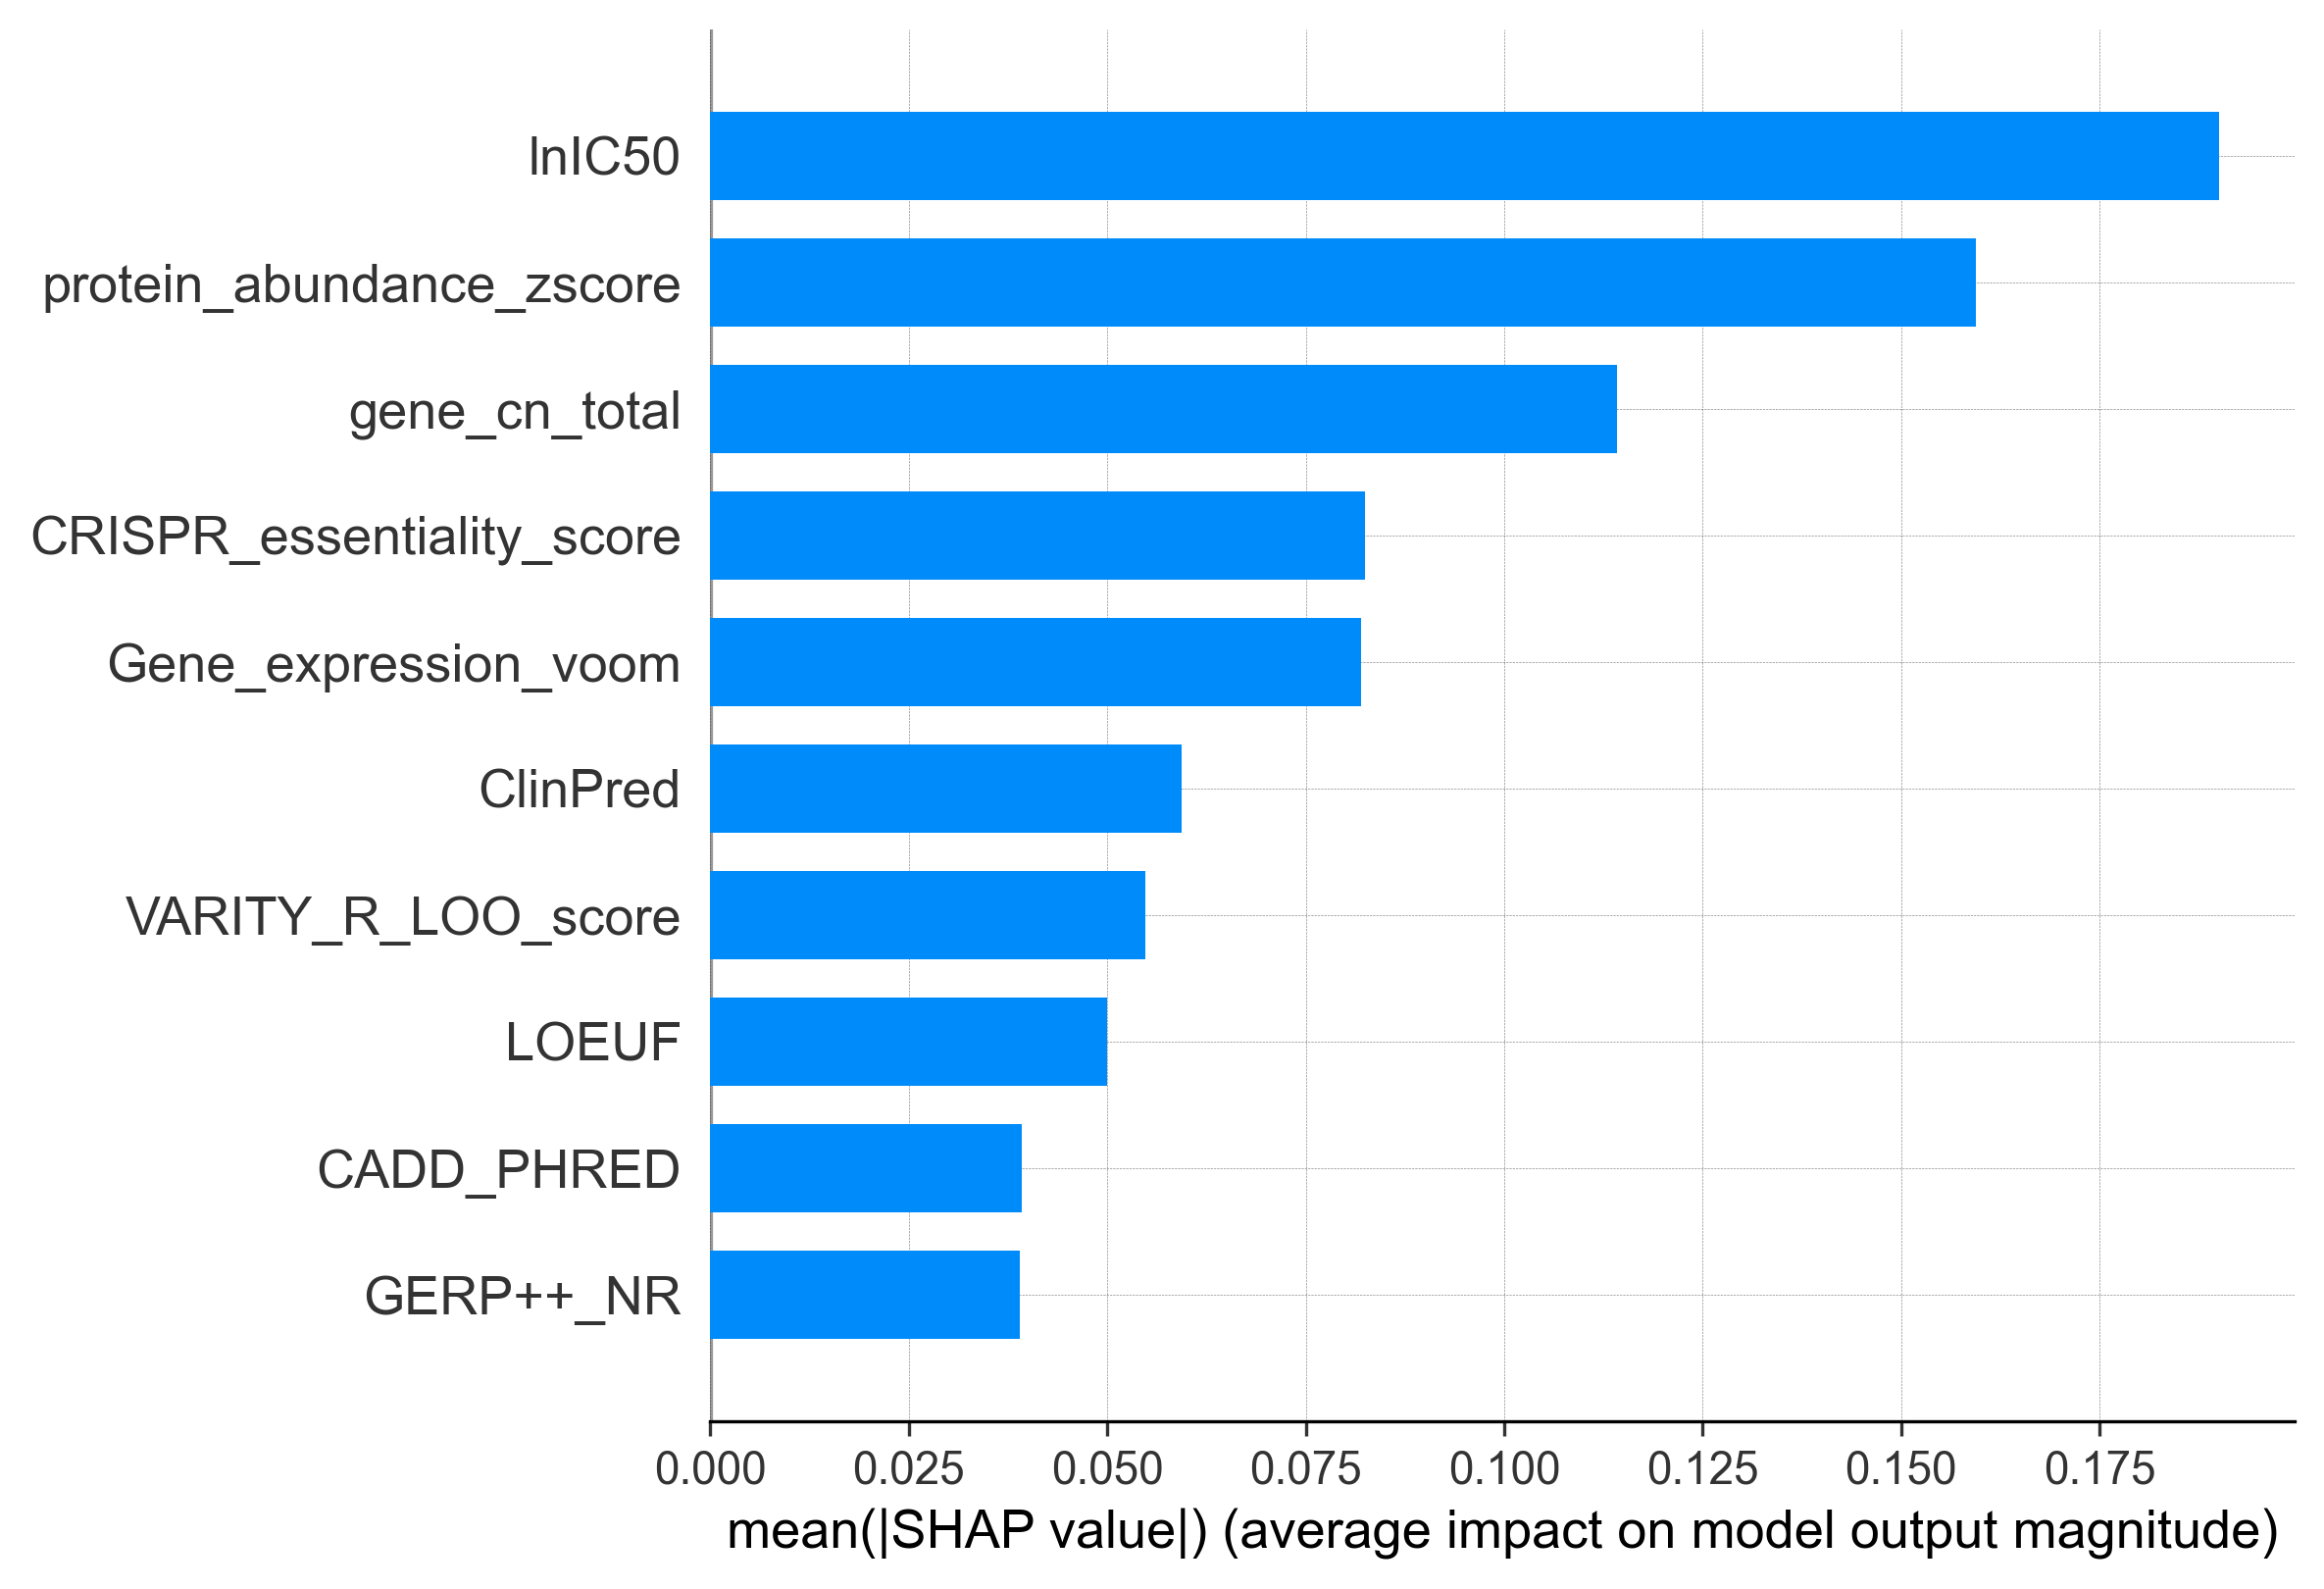

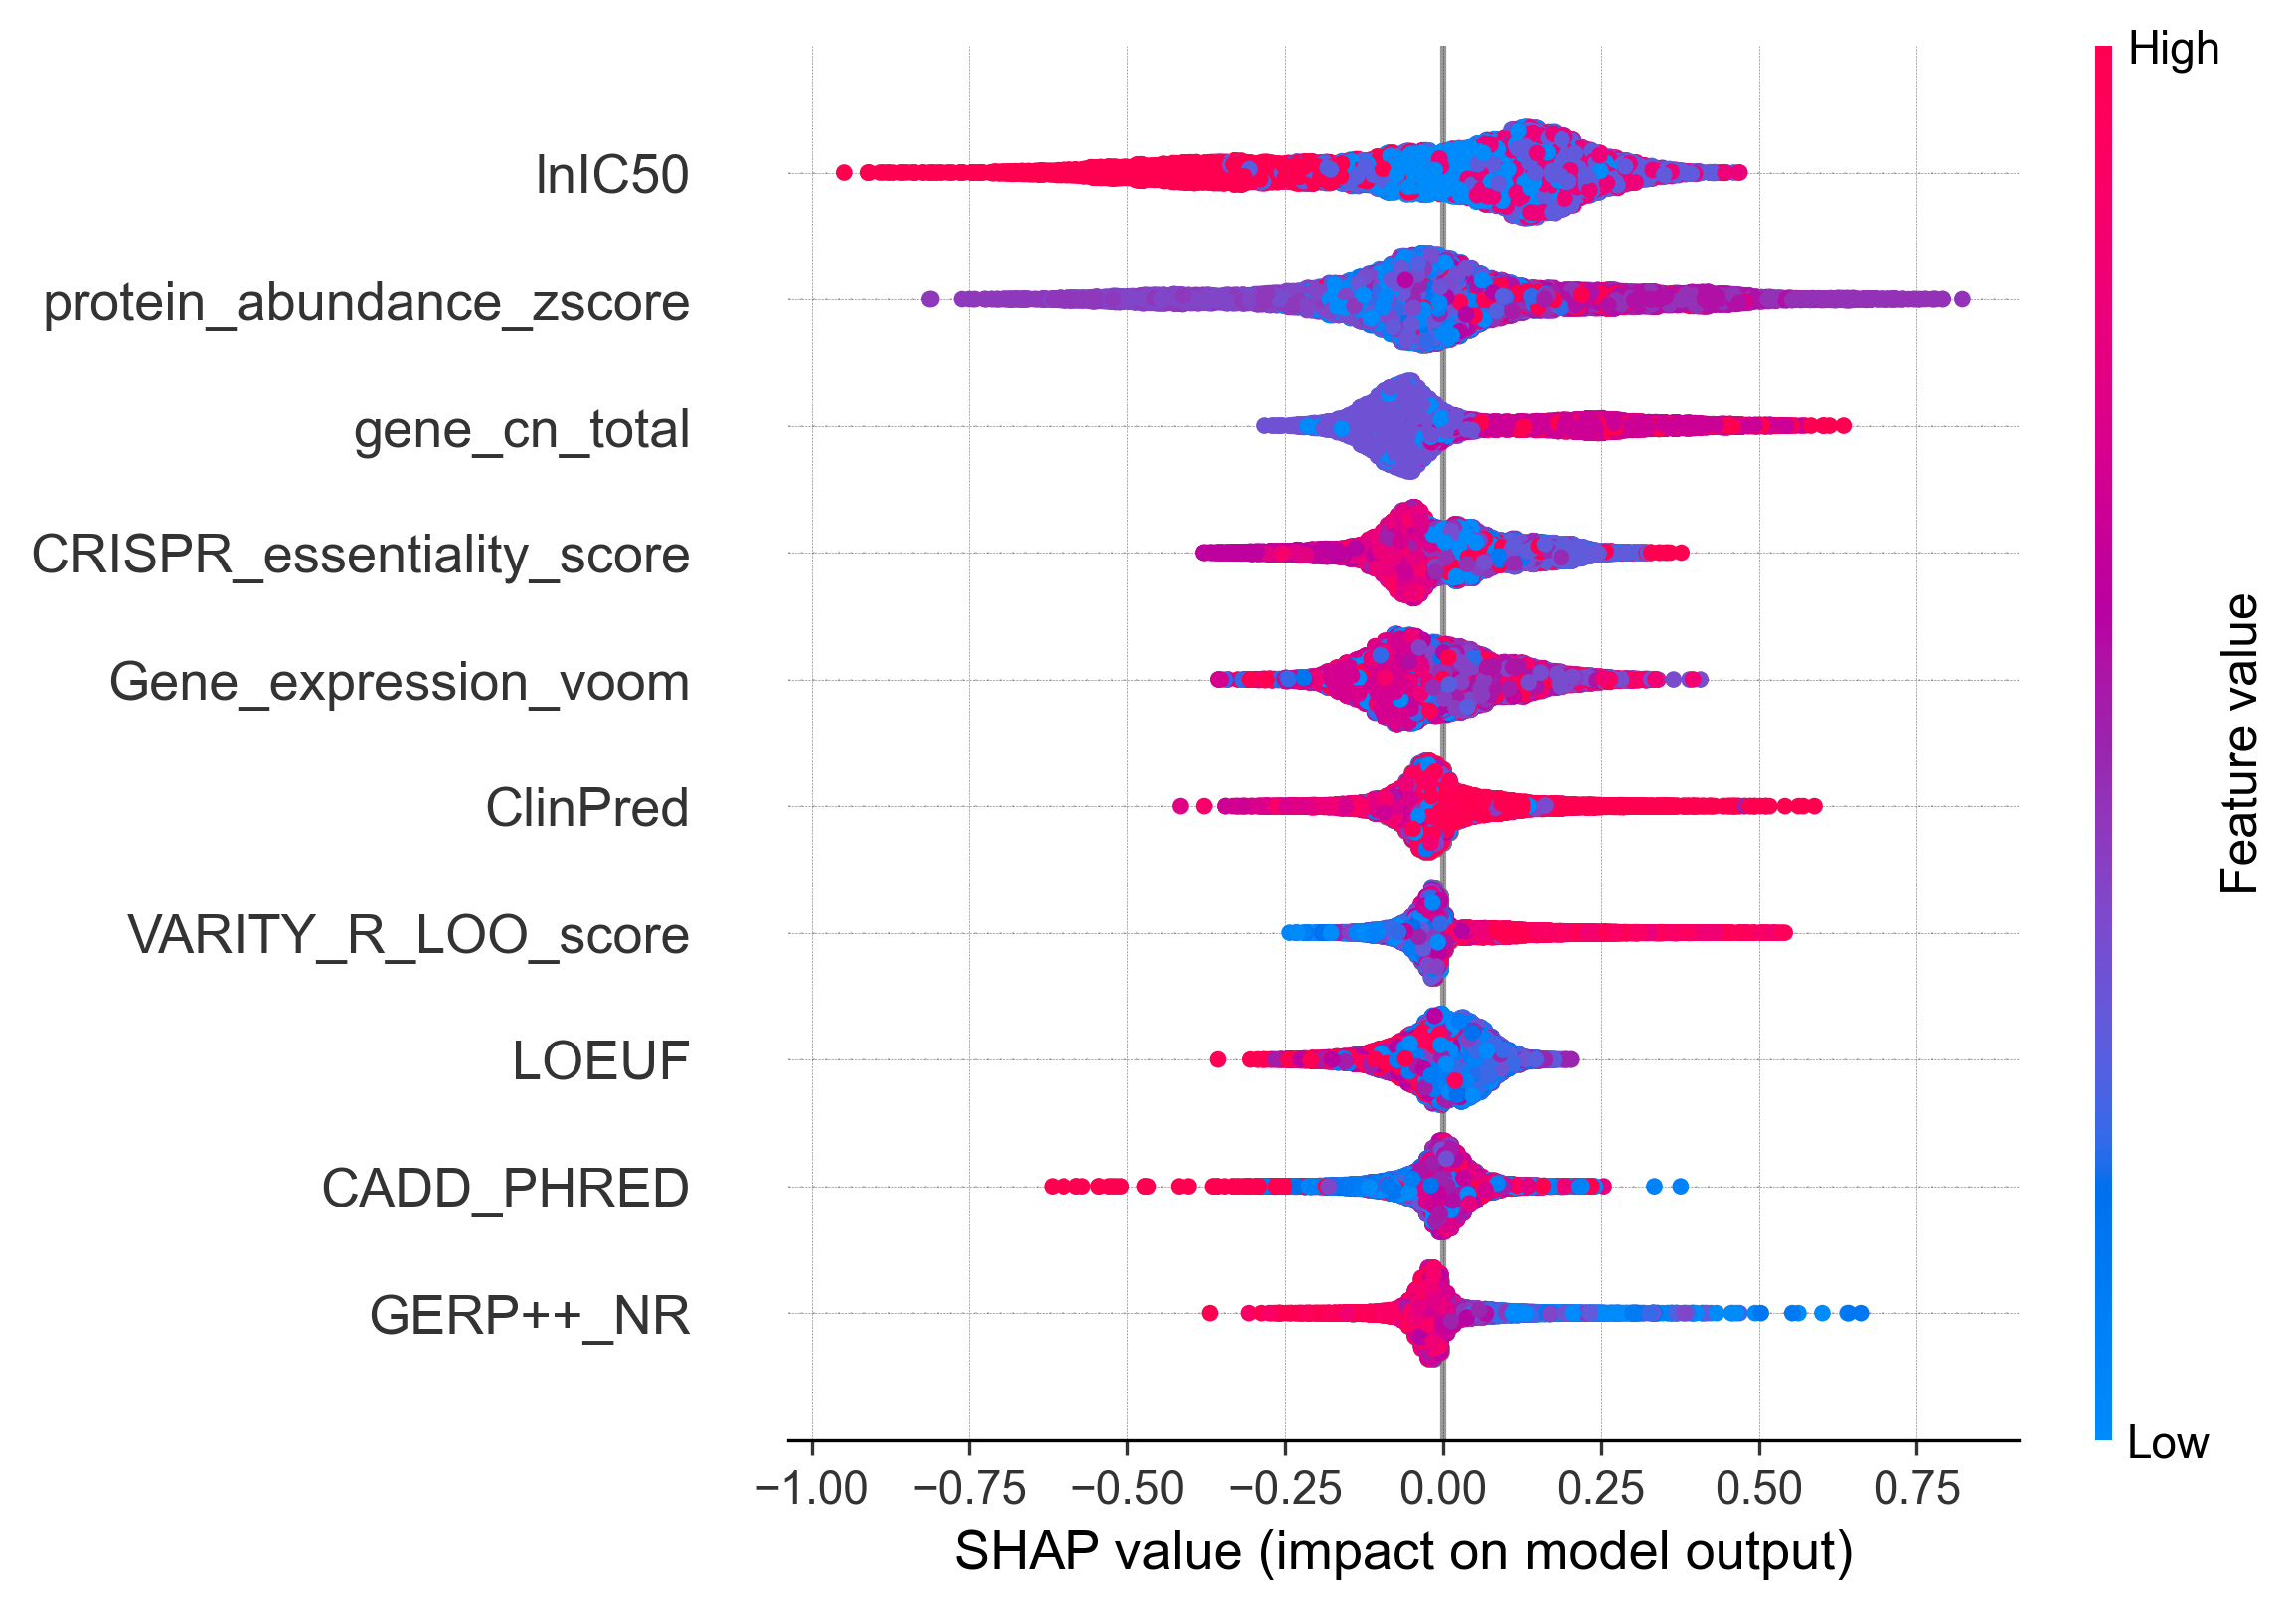

In [34]:
plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class='Resistance', k=10)

# Hyperparameter Tuning

In [55]:
#Split dataset into features and labels
X = annotated_variants_df_balanced.drop(columns=meta_cols + ["Class_encoded"])
y = annotated_variants_df_balanced["Class_encoded"]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2027, 68)
Label vector shape: (2027,)


In [56]:
X.head()

,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
0,3.0,2.0,NaN,0.0,0.903,NaN,0.997184,NaN,0.8033,-0.244790,0.999174,0.560625,-13.162,3.091224,0.180899,4.35,3.44,NaN,0.96529,NaN,NaN,0.685240,-1.0463,0.871099,1.385,NaN,0.0,0.910088,969.0,0.905758,NaN,1.0,7.806,32.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,0.474,1.64656,NaN,6.912422,2.19480,93.95,0.799517,94.146400,939.715467,-0.066729,1.0,14.0,-0.12502,2.0,1.0,0.0,0.0,1.0,0.0,0.724616,2.0,0.0
1,3.0,2.0,NaN,0.0,0.526,NaN,0.980654,NaN,0.8695,-0.086449,0.997541,0.900511,-13.449,4.195272,0.376379,3.86,3.86,NaN,0.81667,NaN,NaN,0.838982,-0.8432,0.879321,1.935,NaN,0.0,0.797818,969.0,0.962908,NaN,1.0,7.985,28.800,9.733,-0.391,9.342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.474,1.23992,0.740776,6.912422,0.85641,86.97,0.790631,69.093103,771.002071,-0.066729,0.0,0.0,-0.12502,2.0,1.0,0.0,0.0,1.0,0.0,0.724616,2.0,0.0
2,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.474,-0.01280,NaN,6.912422,NaN,NaN,0.847171,86.512545,983.000586,-0.066729,0.0,0.0,-0.12502,2.0,1.0,0.0,0.0,1.0,0.0,-0.905239,1.0,0.0
3,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.474,NaN,NaN,6.912422,NaN,NaN,NaN,NaN,NaN,-0.066729,NaN,NaN,-0.12502,2.0,1.0,0.0,0.0,1.0,0.0,-0.905239,1.0,0.0
4,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.474,0.00446,NaN,6.912422,NaN,NaN,NaN,NaN,NaN,-0.066729,0.0,0.0,-0.12502,2.0,1.0,0.0,0.0,1.0,0.0,0.311144,1.0,0.0


### Assessing robustness of Hyperparameters

In [86]:
params = {
    "n_estimators": [50, 100, 200, 300, 500, 700, 1000],  # number of boosting rounds
    "max_depth": [3, 6, 9, 10],                         
    "learning_rate": [0.01, 0.05, 0.07, 0.1, 0.2],              
    "subsample": [0.5, 0.7, 0.85, 1.0],                  # defines the fraction of training instances to be used for each tree
    "colsample_bytree": [0.5, 0.7, 0.85, 1.0],           # feature sampling
    "min_child_weight": [1, 3, 5],                  # min sum of instance weight in child
    "reg_alpha": [0, 0.01, 0.1, 1, 1.5],         # L1 regularization
    "reg_lambda": [0, 0.01, 0.5, 0.7, 1, 1.5],               # L2 regularization
    "gamma": [0, 0.05, 0.1, 0.3, 0.5, 1]                     # min loss reduction to make a further partition
}

In [ ]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
outer_results_per_fold = []  

for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"\nOuter fold {fold_id}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] #X_test and y_test won't be used, it's just to hide part of the data from the hyperparameter tuning

    #Hyperparameter tuning 
    xgb = XGBClassifier(
    objective="multi:softprob", 
    num_class=len(le.classes_), 
    random_state=1
    )

    # Stratified K-Fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    random_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=params,
        n_iter=100,               
        scoring="f1_macro",    
        cv=cv,
        verbose=2,
        random_state=1,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    #Store best params and score for this outer fold
    best_params_fold = random_search.best_params_
    best_score_fold = random_search.best_score_

    outer_results_per_fold.append({
        "fold": fold_id,
        "best_score_inner_cv": best_score_fold,
        **best_params_fold
    })

    results_df = pd.DataFrame(outer_results_per_fold)
    results_df

In [88]:
results_df

,fold,best_score_inner_cv,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree
0,1,0.698712,0.85,1.0,0.01,300,1,6,0.01,1.00
1,2,0.711460,0.70,1.0,0.01,300,1,6,0.01,0.70
2,3,0.706105,0.85,1.3,1.00,1000,3,9,0.01,1.00
3,4,0.691758,0.85,1.3,0.10,300,3,9,0.01,0.85
4,5,0.694344,1.00,0.5,0.10,100,3,9,0.20,1.00


In [70]:
#Best f1 score mean + std variation
mean_best_score = results_df["best_score_inner_cv"].mean()
std_best_score = results_df["best_score_inner_cv"].std()
print(f"\nMean best score across outer folds: {mean_best_score:.4f} ± {std_best_score:.4f}")


Mean best score across outer folds: 0.7005 ± 0.0082


In [71]:
results_df["learning_rate"].value_counts(normalize=True)

learning_rate
0.01    0.8
0.20    0.2
Name: proportion, dtype: float64

In [80]:
results_df["colsample_bytree"].value_counts(normalize=True)

colsample_bytree
1.00    0.6
0.70    0.2
0.85    0.2
Name: proportion, dtype: float64

In [67]:
results_df.to_csv("/Users/carolinapinto/desktop/Tese/xgb_hyperparameter_tuning_outer_cv_results.csv", index=False)

## Optuna Bayesian Optimization

In [59]:
#Define objective function for Optuna
def objective(trial):
    params ={
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000 ),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.5),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'objective': "multi:softprob",
        'num_class': len(le.classes_),
        'random_state': 1,
        'n_jobs': -1
    }
    
    #Stratified Cross Validation
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    cv_fold_scores = []
    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = XGBClassifier(**params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        score = f1_score(y_test, y_pred, average='macro')
        cv_fold_scores.append(score)

    avg_score = np.mean(cv_fold_scores)
    return avg_score

In [60]:
#Define study and optimize
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=2))
study.optimize(objective, n_trials=500)

[I 2026-01-26 18:12:08,407] A new study created in memory with name: no-name-ed108087-1257-4092-a8f4-45a17dcd810a
[I 2026-01-26 18:12:14,521] Trial 0 finished with value: 0.6859516501890426 and parameters: {'n_estimators': 492, 'max_depth': 3, 'learning_rate': 0.16940211858482565, 'subsample': 0.7176611963091384, 'colsample_bytree': 0.7101839010437445, 'min_child_weight': 2, 'reg_alpha': 0.30697295105676375, 'reg_lambda': 0.9289064495259955, 'gamma': 0.29965467367452314}. Best is trial 0 with value: 0.6859516501890426.
[I 2026-01-26 18:12:19,756] Trial 1 finished with value: 0.6923685915414909 and parameters: {'n_estimators': 340, 'max_depth': 7, 'learning_rate': 0.16345120734034133, 'subsample': 0.5672899726724667, 'colsample_bytree': 0.7567890606328732, 'min_child_weight': 1, 'reg_alpha': 1.1780027217250102, 'reg_lambda': 1.2809629389592332, 'gamma': 0.4942368373819278}. Best is trial 1 with value: 0.6923685915414909.
[I 2026-01-26 18:12:30,838] Trial 2 finished with value: 0.6759583

In [61]:
study.best_value

0.7130752895925412

In [62]:
study.best_params


{'n_estimators': 313,
 'max_depth': 8,
 'learning_rate': 0.02520202150916965,
 'subsample': 0.830163825628214,
 'colsample_bytree': 0.5005784890800998,
 'min_child_weight': 1,
 'reg_alpha': 0.5493469089396569,
 'reg_lambda': 0.6081198227329266,
 'gamma': 0.13861550829114033}

In [27]:
study.trials_dataframe().sort_values("value", ascending=False).head(20)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
267,267,0.713854,2026-01-25 16:43:45.655608,2026-01-25 16:43:50.637276,0 days 00:00:04.981668,0.561543,0.648565,0.080444,6,1,785,0.978668,0.389956,0.987777,COMPLETE
317,317,0.711716,2026-01-25 16:47:38.258580,2026-01-25 16:47:42.296729,0 days 00:00:04.038149,0.579381,0.629655,0.082222,6,1,477,1.050449,0.152673,0.970054,COMPLETE
403,403,0.711265,2026-01-25 16:54:25.368385,2026-01-25 16:54:30.118842,0 days 00:00:04.750457,0.554338,0.620453,0.068311,6,1,512,0.636553,0.404695,0.969646,COMPLETE
221,221,0.709770,2026-01-25 16:40:09.761133,2026-01-25 16:40:13.923803,0 days 00:00:04.162670,0.537115,0.622291,0.066009,6,1,505,0.900695,0.335356,0.987312,COMPLETE
389,389,0.709703,2026-01-25 16:53:03.914825,2026-01-25 16:53:09.546184,0 days 00:00:05.631359,0.567368,0.558087,0.063055,6,1,539,0.804970,0.444492,0.967505,COMPLETE
496,496,0.709507,2026-01-25 17:01:55.954010,2026-01-25 17:02:00.525366,0 days 00:00:04.571356,0.571856,0.629251,0.063894,6,1,468,0.380665,0.342996,0.935986,COMPLETE
126,126,0.709470,2026-01-25 16:29:38.508751,2026-01-25 16:29:45.351709,0 days 00:00:06.842958,0.569171,0.621962,0.039203,8,1,467,0.113136,0.388999,0.927381,COMPLETE
243,243,0.709150,2026-01-25 16:41:56.903401,2026-01-25 16:42:02.177891,0 days 00:00:05.274490,0.538791,0.608358,0.071286,6,1,531,0.891706,0.264171,0.970067,COMPLETE
261,261,0.709066,2026-01-25 16:43:15.548824,2026-01-25 16:43:21.108467,0 days 00:00:05.559643,0.558770,0.647416,0.058270,6,1,757,1.008289,0.192087,0.982026,COMPLETE
468,468,0.708772,2026-01-25 16:59:49.501899,2026-01-25 16:59:54.538591,0 days 00:00:05.036692,0.550650,0.977288,0.062588,6,1,747,0.686287,0.329916,0.991710,COMPLETE


In [36]:
optuna.visualization.plot_optimization_history(study)

In [37]:
optuna.visualization.plot_param_importances(study)